- amount 
- is_refund
- log_abs_amount


- yearly_income
- total_debt
- income_ratio_region
- log_yearly_income
- log_income_ratio_region


- abs_amount
- amount_income_ratio
- amount_limit_ratio
- log_amount_income_ratio
- log_amount_limit_ratio

In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, 
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

TARGET = "fraud"

%matplotlib inline

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from scipy.stats import ks_2samp
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

LABEL = "fraud"

AMOUNT_RAW = ["amount", "abs_amount", "is_refund"]
AMOUNT_LOG = [
    "log_abs_amount",
    "log_yearly_income",
    "log_amount_income_ratio",
    "log_amount_limit_ratio",
    "log_income_ratio_region",
]
AMOUNT_RATIO = ["amount_income_ratio", "amount_limit_ratio", "income_ratio_region"]
AMOUNT_CONTEXT = ["per_capita_income", "yearly_income", "total_debt"]

df = pd.read_parquet("data")

ALL_AMOUNT_FEATURES = AMOUNT_RAW + AMOUNT_LOG + AMOUNT_RATIO + AMOUNT_CONTEXT
ALL_AMOUNT_FEATURES = [c for c in ALL_AMOUNT_FEATURES if c in df.columns]

In [3]:
def _fmt_int(x, _):
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)

def plot_hist_kde_overlay(df, col, label=LABEL, bins=80, clip_q=(0.001, 0.999)):
    s = df[col].astype(float)
    lo, hi = s.quantile(clip_q[0]), s.quantile(clip_q[1])
    d = df.loc[s.between(lo, hi), [col, label]].dropna()
    x0 = d.loc[d[label] == 0, col].astype(float).to_numpy()
    x1 = d.loc[d[label] == 1, col].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.hist(x0, bins=bins, density=True, alpha=0.35, label="non-fraud")
    ax.hist(x1, bins=bins, density=True, alpha=0.35, label="fraud")

    s0 = pd.Series(x0)
    s1 = pd.Series(x1)
    kde0 = s0.plot(kind="kde", ax=ax)
    kde1 = s1.plot(kind="kde", ax=ax)

    ax.set_title(f"Distribution: {col} (clipped {clip_q[0]:.3f}-{clip_q[1]:.3f} quantile)")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.show()

def plot_box_by_label(df, col, label=LABEL, clip_q=(0.001, 0.999)):
    s = df[col].astype(float)
    lo, hi = s.quantile(clip_q[0]), s.quantile(clip_q[1])
    d = df.loc[s.between(lo, hi), [col, label]].dropna()

    fig, ax = plt.subplots(figsize=(8.8, 4.5))
    ax.boxplot(
        [d.loc[d[label] == 0, col].astype(float).to_numpy(),
         d.loc[d[label] == 1, col].astype(float).to_numpy()],
        labels=["non-fraud", "fraud"],
        showfliers=False,
    )
    ax.set_title(f"Boxplot by label: {col} (clipped)")
    ax.set_ylabel(col)
    ax.grid(True, axis="y", alpha=0.25)
    plt.show()

def decile_table(df, col, label=LABEL):
    d = df[[col, label]].dropna().copy()
    d["decile"] = pd.qcut(d[col].astype(float), 10, duplicates="drop")
    base = float(d[label].mean())
    g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})
    g["lift_vs_base"] = g["fraud_rate"] / base if base > 0 else np.nan
    return g, base

def plot_decile_fraud_rate(df, col, label=LABEL):
    tab, base = decile_table(df, col, label=label)
    x = np.arange(len(tab))
    y = tab["fraud_rate"].to_numpy()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(x, y, marker="o")
    ax.axhline(base, linestyle="--", linewidth=1)
    ax.set_title(f"Decile fraud rate: {col} (base={base:.4f})")
    ax.set_xlabel("Decile (low → high)")
    ax.set_ylabel("Fraud rate")
    ax.set_xticks(x)
    ax.set_xticklabels([str(i+1) for i in range(len(tab))])
    ax.grid(True, alpha=0.25)
    plt.show()

def ks_stat(df, col, label=LABEL, clip_q=(0.001, 0.999)):
    s = df[col].astype(float)
    lo, hi = s.quantile(clip_q[0]), s.quantile(clip_q[1])
    d = df.loc[s.between(lo, hi), [col, label]].dropna()
    x0 = d.loc[d[label] == 0, col].astype(float)
    x1 = d.loc[d[label] == 1, col].astype(float)
    if x0.empty or x1.empty:
        return np.nan
    return float(ks_2samp(x1, x0).statistic)

def pr_auc_single(df, col, label=LABEL):
    d = df[[col, label]].dropna()
    if d.empty:
        return np.nan
    return float(average_precision_score(d[label].astype(int), d[col].astype(float)))

def top_decile_lift(y_true, score, q=0.90):
    y = pd.Series(y_true).astype(int).reset_index(drop=True)
    s = pd.Series(score).astype(float).reset_index(drop=True)
    base_rate = float(y.mean())
    thr = float(np.quantile(s, q))
    top_mask = s >= thr
    top_n = int(top_mask.sum())
    if top_n == 0 or base_rate == 0:
        return {"base_rate": base_rate, "top_decile_rate": np.nan, "top_decile_lift": np.nan, "top_n": top_n, "thr": thr}
    top_rate = float(y[top_mask].mean())
    return {"base_rate": base_rate, "top_decile_rate": top_rate, "top_decile_lift": float(top_rate / base_rate), "top_n": top_n, "thr": thr}

기본 분포 확인

negative amount rate: 0.00561930790313439


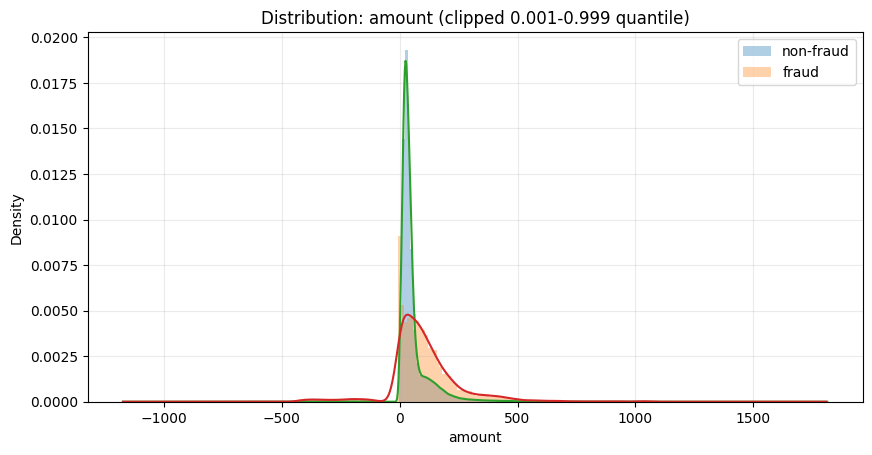

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


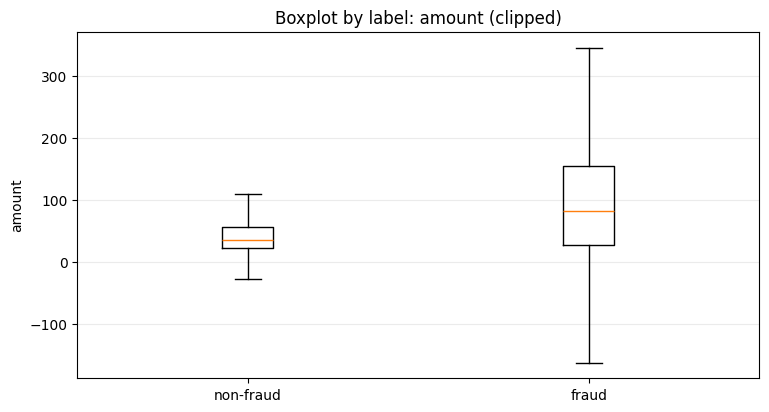

In [4]:
neg_rate = float((df["amount"] < 0).mean()) if "amount" in df.columns else np.nan
print("negative amount rate:", neg_rate)

if "amount" in df.columns:
    plot_hist_kde_overlay(df, "amount", bins=120, clip_q=(0.001, 0.999))
    plot_box_by_label(df, "amount", clip_q=(0.001, 0.999))

is_refund 단독 분석 (fraud rate 비교)

,count,fraud_rate
is_refund,,
0,512293,0.012151
1,2895,0.106390


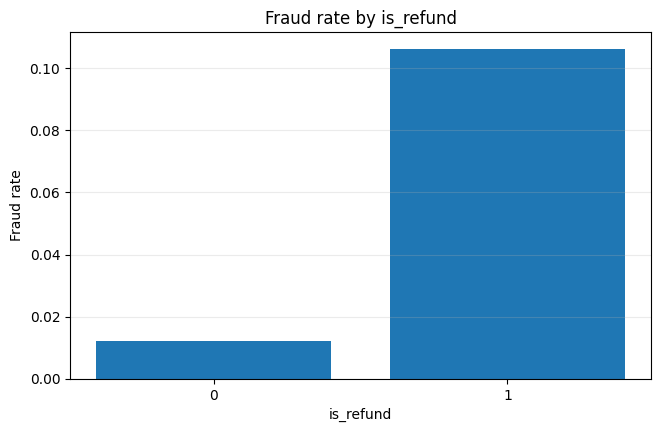

In [5]:
if "is_refund" in df.columns:
    refund_summary = df.groupby("is_refund")[LABEL].agg(count="count", fraud_rate="mean")
    display(refund_summary)

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    x = refund_summary.index.astype(str).to_list()
    y = refund_summary["fraud_rate"].to_numpy()
    ax.bar(x, y)
    ax.set_title("Fraud rate by is_refund")
    ax.set_xlabel("is_refund")
    ax.set_ylabel("Fraud rate")
    ax.grid(True, axis="y", alpha=0.25)
    plt.show()

구조적 리스크 변수\
Stage1에서도 반드시 포함

amount / log_abs_amount — 박스플롯 + KDE + Decile fraud rate

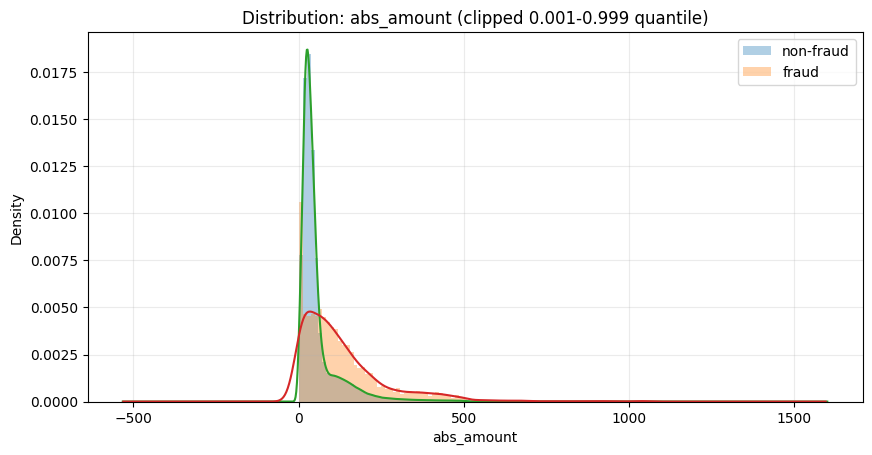

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


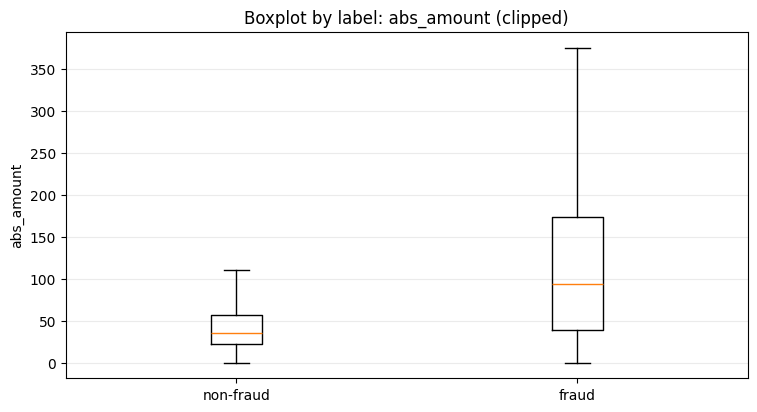

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


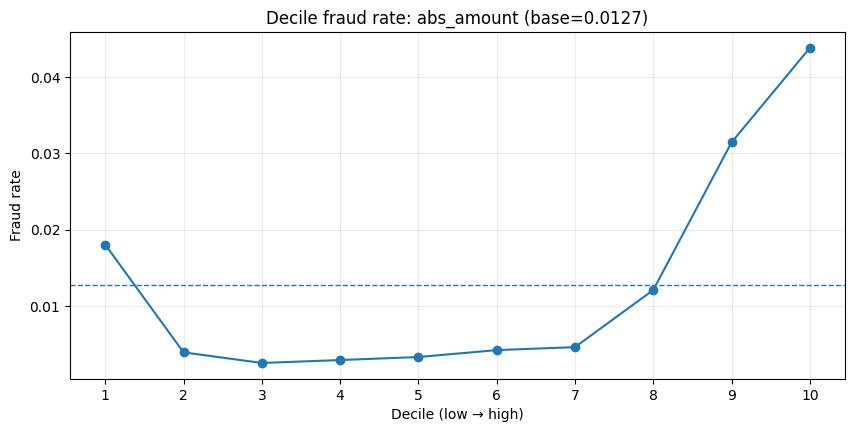

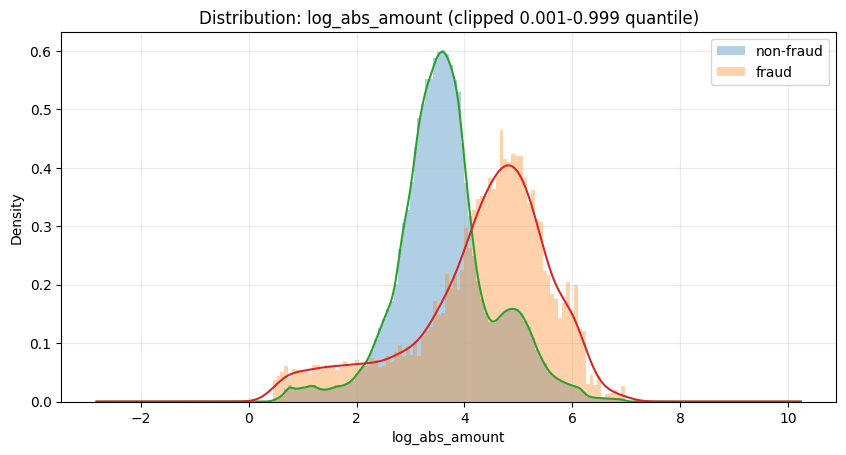

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


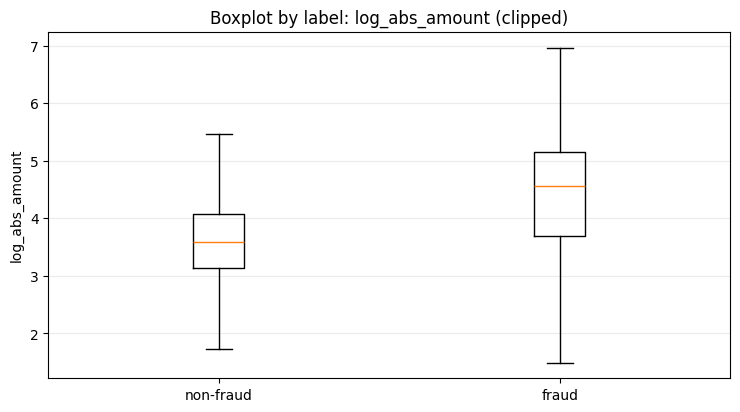

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


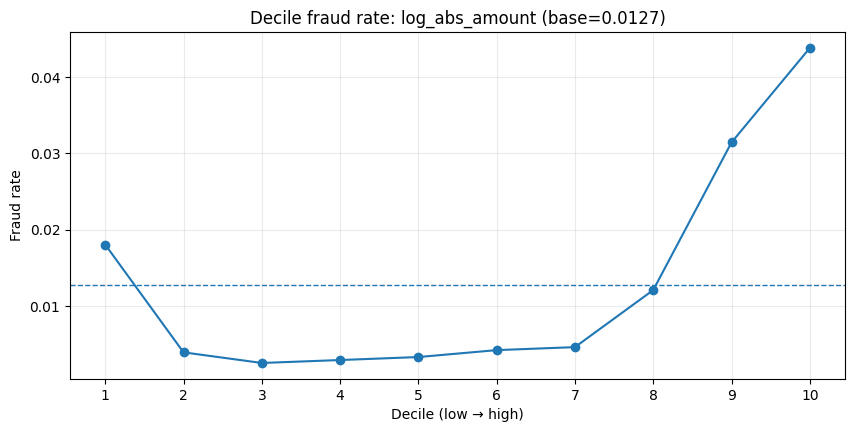

In [6]:
for col in ["abs_amount", "log_abs_amount"]:
    if col in df.columns:
        plot_hist_kde_overlay(df, col, bins=90, clip_q=(0.001, 0.999))
        plot_box_by_label(df, col, clip_q=(0.001, 0.999))
        plot_decile_fraud_rate(df, col)

소득/부채 계열 — yearly_income, per_capita_income, total_debt

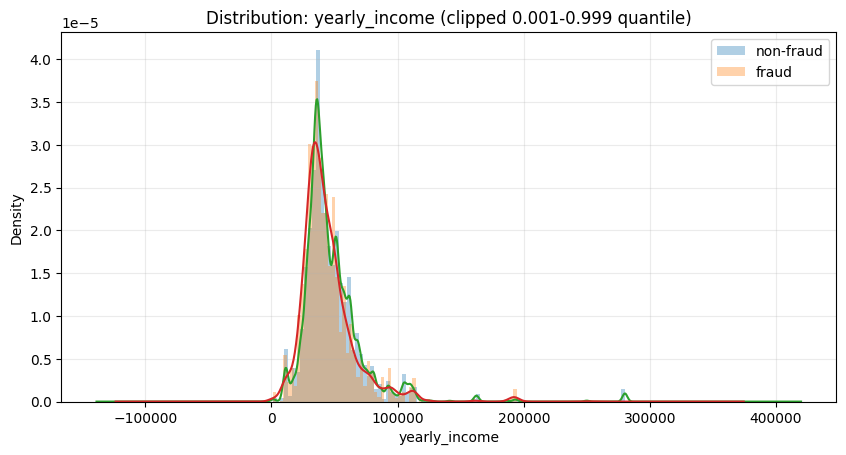

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


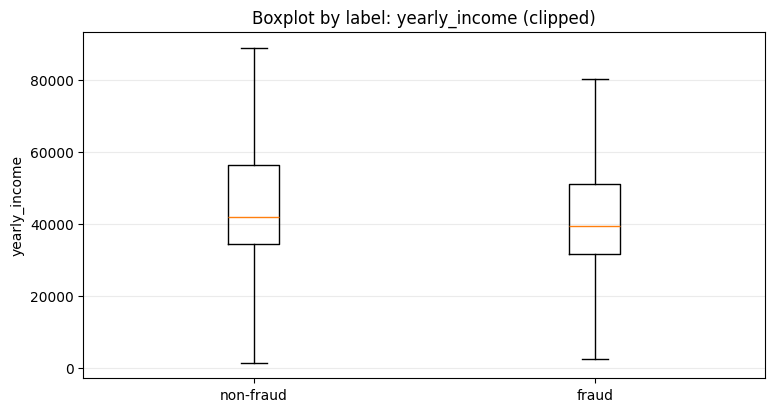

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


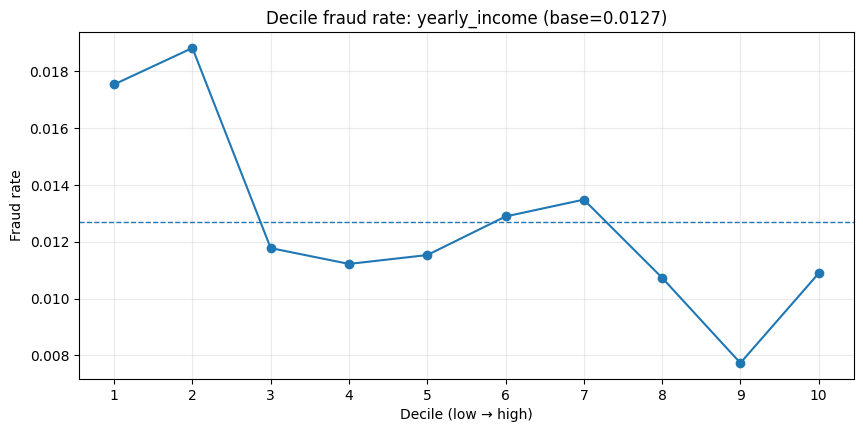

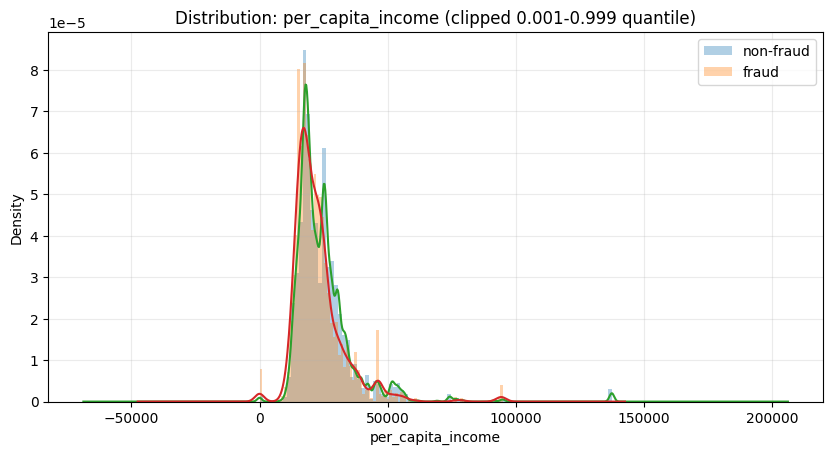

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


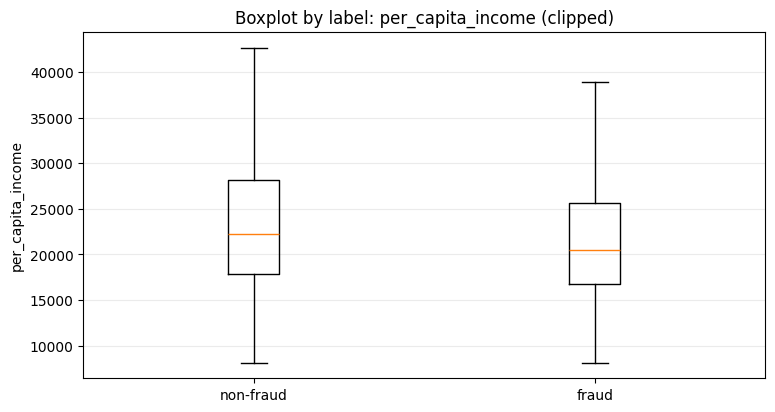

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


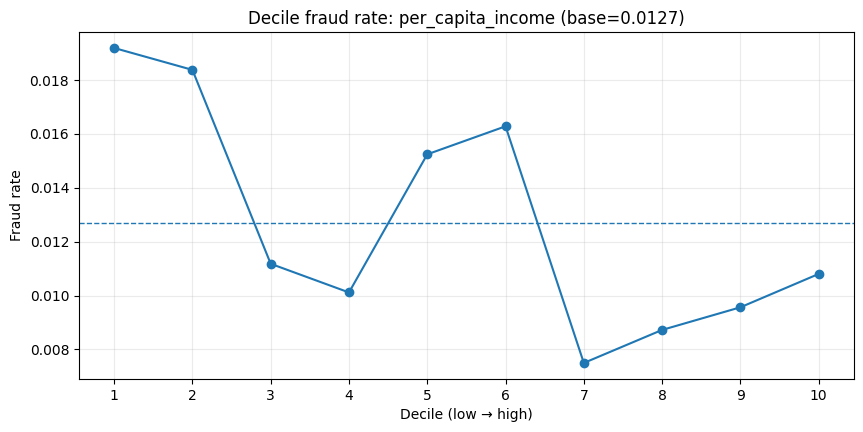

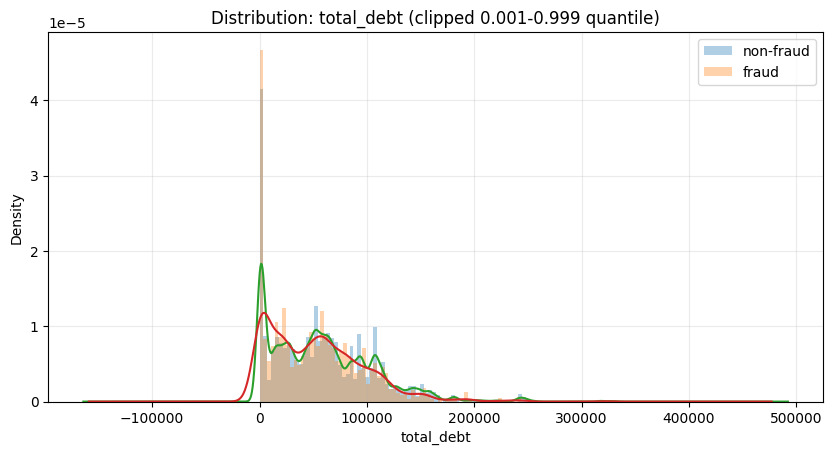

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


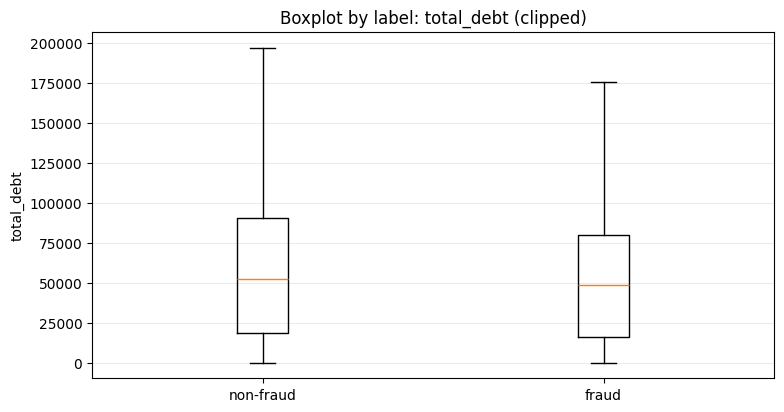

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


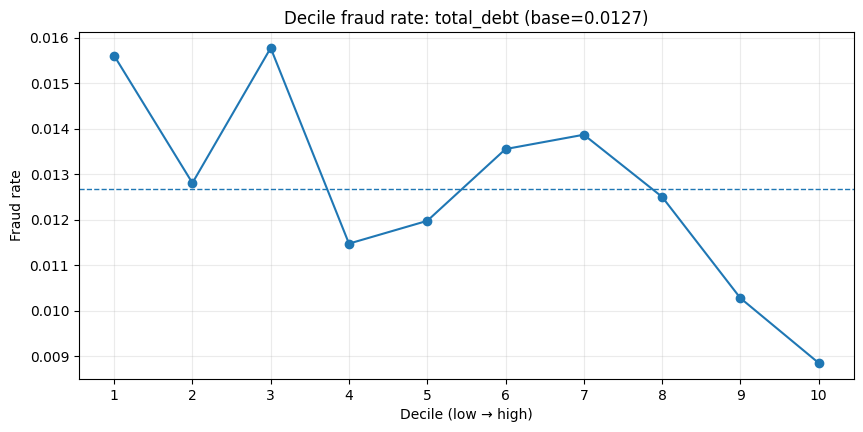

In [7]:
income_cols = [c for c in ["yearly_income", "per_capita_income", "total_debt"] if c in df.columns]
for col in income_cols:
    plot_hist_kde_overlay(df, col, bins=90, clip_q=(0.001, 0.999))
    plot_box_by_label(df, col, clip_q=(0.001, 0.999))
    plot_decile_fraud_rate(df, col)

비율 피처 계열 — amount_income_ratio, amount_limit_ratio, income_ratio_region

amount_income_ratio inf: 0 nan: 0


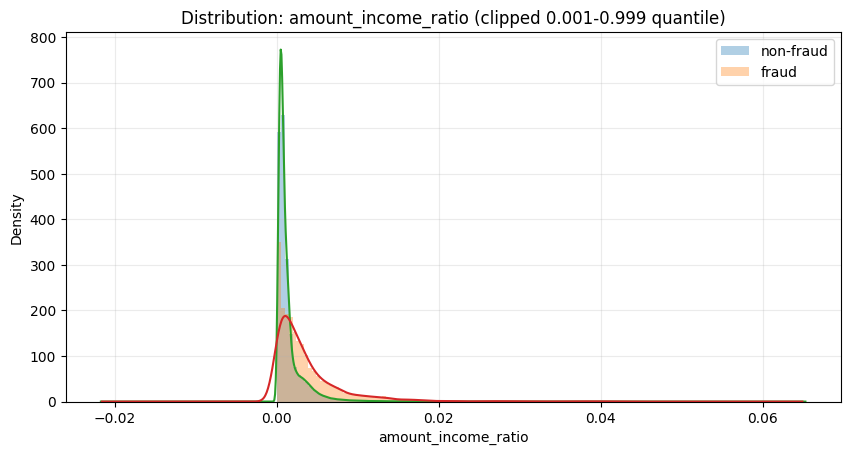

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


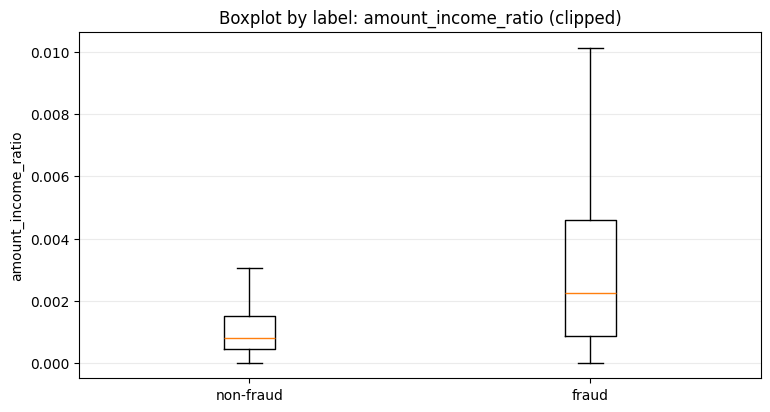

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


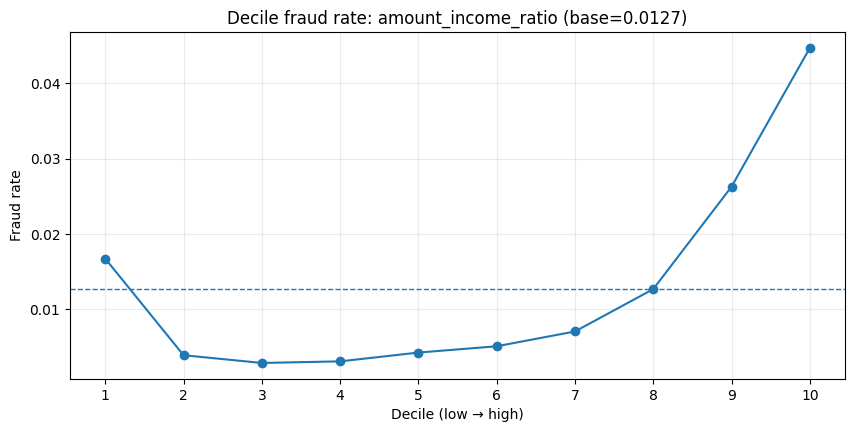

amount_limit_ratio inf: 0 nan: 0


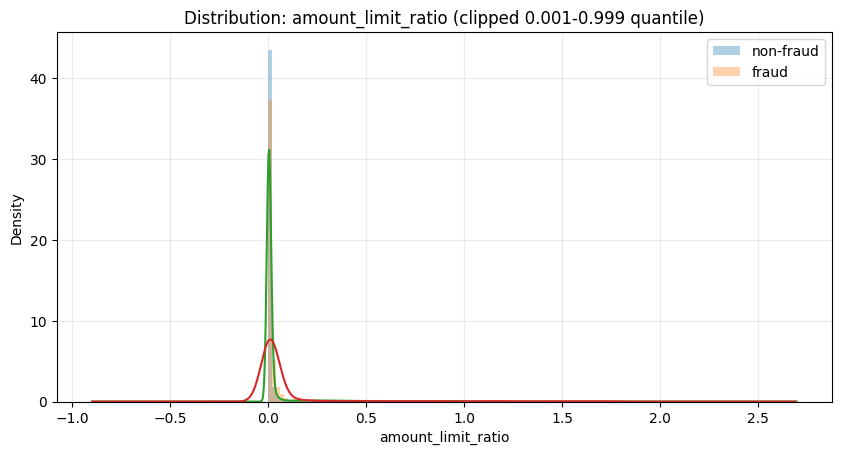

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


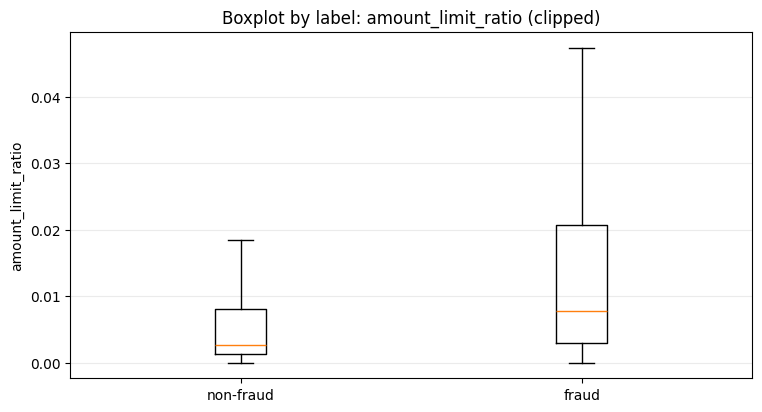

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


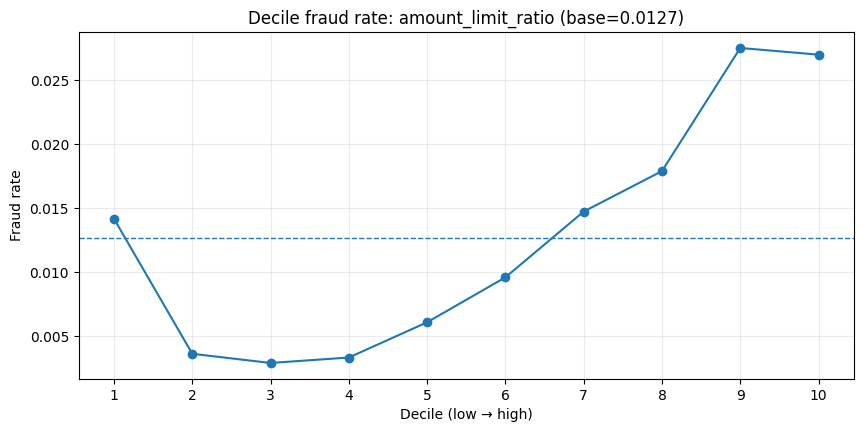

income_ratio_region inf: 0 nan: 0


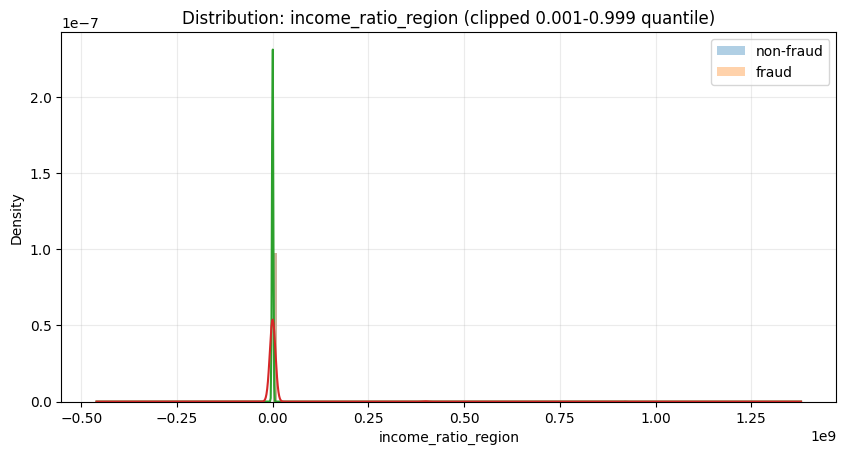

/tmp/ipykernel_3597804/3200772682.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


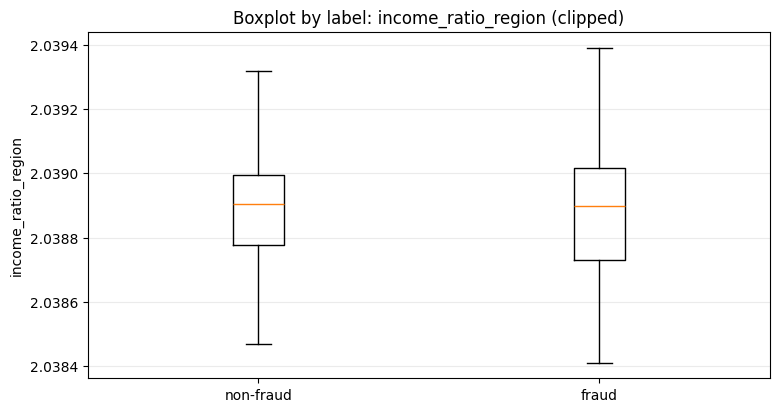

/tmp/ipykernel_3597804/3200772682.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby("decile")[label].agg(["count", "mean"]).rename(columns={"mean": "fraud_rate"})


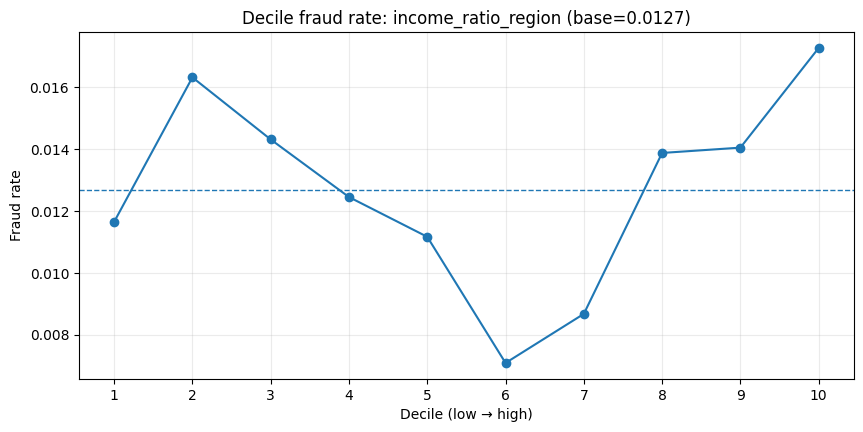

In [8]:
ratio_cols = [c for c in ["amount_income_ratio", "amount_limit_ratio", "income_ratio_region"] if c in df.columns]

for col in ratio_cols:
    inf_cnt = int(np.isinf(df[col]).sum()) if col in df.columns else 0
    nan_cnt = int(df[col].isna().sum()) if col in df.columns else 0
    print(col, "inf:", inf_cnt, "nan:", nan_cnt)

    plot_hist_kde_overlay(df, col, bins=90, clip_q=(0.001, 0.999))
    plot_box_by_label(df, col, clip_q=(0.001, 0.999))
    plot_decile_fraud_rate(df, col)

raw vs log 비교 (KS + PR-AUC)

In [9]:
pairs = []
if "abs_amount" in df.columns and "log_abs_amount" in df.columns:
    pairs.append(("abs_amount", "log_abs_amount"))

if "yearly_income" in df.columns and "log_yearly_income" in df.columns:
    pairs.append(("yearly_income", "log_yearly_income"))

if "amount_income_ratio" in df.columns and "log_amount_income_ratio" in df.columns:
    pairs.append(("amount_income_ratio", "log_amount_income_ratio"))

if "amount_limit_ratio" in df.columns and "log_amount_limit_ratio" in df.columns:
    pairs.append(("amount_limit_ratio", "log_amount_limit_ratio"))

compare_rows = []
for raw_col, log_col in pairs:
    compare_rows.append({
        "raw": raw_col,
        "log": log_col,
        "KS_raw": ks_stat(df, raw_col),
        "KS_log": ks_stat(df, log_col),
        "PR_AUC_raw": pr_auc_single(df, raw_col),
        "PR_AUC_log": pr_auc_single(df, log_col),
    })

compare_df = pd.DataFrame(compare_rows)
display(compare_df)

,raw,log,KS_raw,KS_log,PR_AUC_raw,PR_AUC_log
0,abs_amount,log_abs_amount,0.420464,0.420464,0.040454,0.040454
1,yearly_income,log_yearly_income,0.097682,0.097682,0.011021,0.011021
2,amount_income_ratio,log_amount_income_ratio,0.383926,0.383926,0.044769,0.044769
3,amount_limit_ratio,log_amount_limit_ratio,0.286522,0.286522,0.071137,0.071137


raw vs log가 완전히 동일 _ 순위 기반이니까 당연

차이는 모델 선형성 / 안정성 / 극단값 완화에서 발생


Add-one Δ Lift (로지스틱 기준)

,candidate,PR_AUC,PR_AUC_delta,TopDecileLift,Lift_delta
6,amount_limit_ratio,0.083801,0.036141,3.940245,0.328991
3,log_amount_limit_ratio,0.098638,0.050978,3.680112,0.068859
8,per_capita_income,0.050024,0.002365,3.680112,0.068859
5,amount_income_ratio,0.050866,0.003206,3.672461,0.061208
9,yearly_income,0.049284,0.001624,3.672461,0.061208
2,log_amount_income_ratio,0.050750,0.003091,3.657159,0.045906
4,log_income_ratio_region,0.047743,0.000083,3.649508,0.038255
10,total_debt,0.048582,0.000922,3.634206,0.022953
7,income_ratio_region,0.047620,-0.000040,3.611254,0.000000
1,abs_amount,0.047018,-0.000642,3.595952,-0.015302


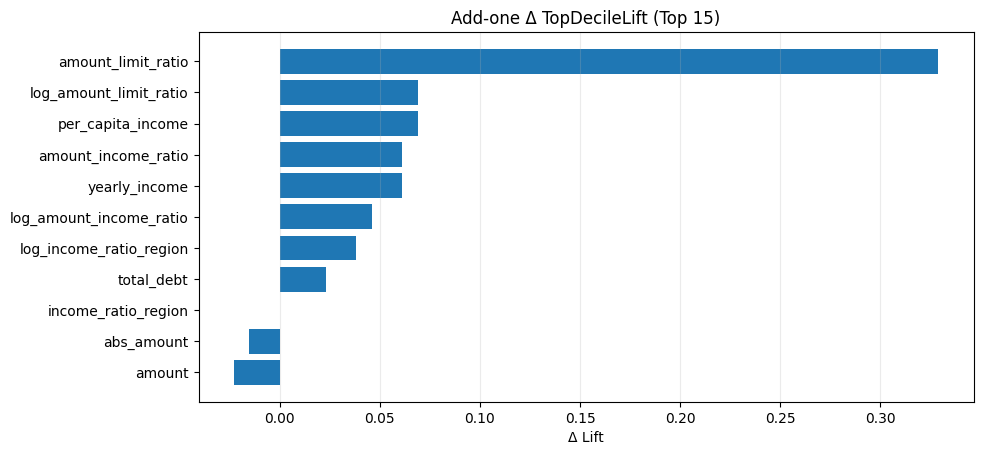

In [11]:
base_cols = [c for c in ["log_abs_amount", "is_refund", "log_yearly_income"] if c in df.columns]
cand_cols = [c for c in ALL_AMOUNT_FEATURES if c in df.columns and c not in base_cols and c != LABEL]

d = df[base_cols + cand_cols + [LABEL]].replace([np.inf, -np.inf], np.nan).dropna()
X = d[base_cols + cand_cols]
y = d[LABEL].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def fit_score(cols):
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(max_iter=500, n_jobs=None, solver="lbfgs"))
    ])
    pipe.fit(X_tr[cols], y_tr)
    score = pipe.predict_proba(X_te[cols])[:, 1]
    pr = float(average_precision_score(y_te, score))
    lift = top_decile_lift(y_te, score)["top_decile_lift"]
    return pr, lift

base_pr, base_lift = fit_score(base_cols)

rows = []
for c in cand_cols:
    pr, lift = fit_score(base_cols + [c])
    rows.append({
        "candidate": c,
        "PR_AUC": pr,
        "PR_AUC_delta": pr - base_pr,
        "TopDecileLift": lift,
        "Lift_delta": lift - base_lift
    })

add1_df = pd.DataFrame(rows).sort_values(["Lift_delta", "PR_AUC_delta"], ascending=False)
display(add1_df)

fig, ax = plt.subplots(figsize=(10, 4.8))
top = add1_df.head(15).iloc[::-1]
ax.barh(top["candidate"], top["Lift_delta"])
ax.set_title("Add-one Δ TopDecileLift (Top 15)")
ax.set_xlabel("Δ Lift")
ax.grid(True, axis="x", alpha=0.25)
plt.show()

**per_capita_income**

KS 0.11 정도

Add-one lift 상승

하지만 분리력 자체는 약하다.




**DROP**


total_debt (0.023)

income_ratio_region (0.000)

abs_amount (-)

amount (-)

**ratio 계열이 진짜 핵심**

amount_income_ratio

KS 0.38

decile 10에서 fraud 급증

boxplot 분리 명확

amount_limit_ratio

KS 0.28

PR_AUC_single 가장 높음 (0.071)

Add-one Lift Δ = 0.33 (압도적)

Fraud는 절대 금액보다 개인 대비 과도한 지출에서 발생한다.

단조 로그 변환은 분리력을 바꾸지 않는다 (rank metric 동일).

Ratio 계열이 raw 금액보다 행동적 리스크를 더 잘 포착한다.

income 자체는 weak signal이지만 ratio를 통해 의미가 생긴다.

raw/log 동시 사용은 다중공선성 위험이 높다.

### ***amount_income_ratio***

In [12]:
if "yearly_income" in df.columns:
    s = df["yearly_income"]
    desc = s.describe(percentiles=[.001, .01, .05, .5, .95, .99, .999])
    print(desc)
    mask = s < 1000
    print("yearly_income < 1000 count:", int(mask.sum()))
    if mask.any():
        print("fraud rate (yearly_income < 1000):", float(df.loc[mask, LABEL].mean()))
        print("base fraud rate:", float(df[LABEL].mean()))

count    515188.000000
mean      48212.687500
std       26821.412109
min           1.000000
0.1%        920.000000
1%        10869.000000
5%        22726.000000
50%       41902.000000
95%       92017.000000
99%      161276.000000
99.9%    280199.000000
max      280199.000000
Name: yearly_income, dtype: float64
yearly_income < 1000 count: 643
fraud rate (yearly_income < 1000): 0.06376360808709176
base fraud rate: 0.012680807782789972


> yearly_income 지나치게 작은 값 처리

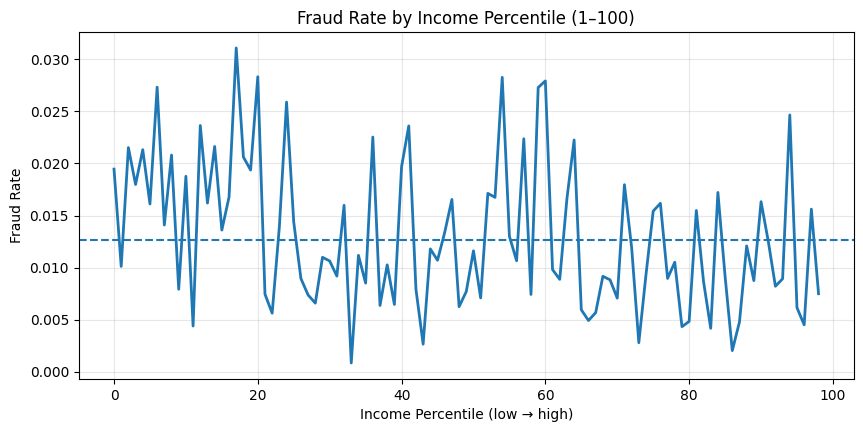

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL = "fraud"

tmp = df[["yearly_income", LABEL]].dropna().copy()
tmp["centile"] = pd.qcut(tmp["yearly_income"], 100, duplicates="drop")

g = tmp.groupby("centile", observed=True)[LABEL].mean().reset_index(drop=True)

base = tmp[LABEL].mean()

plt.figure(figsize=(10,4.5))
plt.plot(g, linewidth=2)
plt.axhline(base, linestyle="--")
plt.title("Fraud Rate by Income Percentile (1–100)")
plt.xlabel("Income Percentile (low → high)")
plt.ylabel("Fraud Rate")
plt.grid(alpha=0.3)
plt.show()

In [14]:
df[df["amount_income_ratio"] > 1]["yearly_income"].describe()

count     55.000000
mean      21.127274
std      104.273155
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      553.000000
Name: yearly_income, dtype: float64

**ratio 폭발 발생 구간 잡아야 함**

ratio > 1은 거의 income ≤ 553

income ≤ 1000은 통계적으로 하위 0.1%

In [15]:
LABEL = "fraud"

RATIO_COL = "amount_income_ratio"
INCOME_COL = "yearly_income"

CLIP_LOWER = 1000.0
RANDOM_STATE = 42
TEST_SIZE = 0.2


def top_decile_lift(y_true, score, q=0.90):
    y = pd.Series(y_true).astype(int).reset_index(drop=True)
    s = pd.Series(score).astype(float).reset_index(drop=True)

    base_rate = float(y.mean())
    thr = float(np.quantile(s, q))

    top = s >= thr
    top_n = int(top.sum())
    if top_n == 0 or base_rate == 0:
        return {"base_rate": base_rate, "top_decile_rate": np.nan, "top_decile_lift": np.nan, "top_n": top_n, "thr": thr}

    top_rate = float(y[top].mean())
    return {"base_rate": base_rate, "top_decile_rate": top_rate, "top_decile_lift": float(top_rate / base_rate), "top_n": top_n, "thr": thr}


def fit_eval_logistic_addone(df_in, base_cols, add_col):
    cols = base_cols + [add_col]
    d = df_in[cols + [LABEL]].replace([np.inf, -np.inf], np.nan).dropna()
    X = d[cols]
    y = d[LABEL].astype(int)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    pipe = Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, solver="lbfgs")),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict_proba(X_te)[:, 1]

    pr = float(average_precision_score(y_te, pred))
    lift = float(top_decile_lift(y_te, pred)["top_decile_lift"])
    return pr, lift


# Build three variants 

dfv = df.copy()

# (1) Original ratio
dfv["ratio_orig"] = dfv[RATIO_COL].astype(float)

# (2) Clip income then recompute ratio
income_clip = dfv[INCOME_COL].astype(float).clip(lower=CLIP_LOWER)
dfv["ratio_clip"] = dfv["abs_amount"].astype(float) / income_clip

# (3) Original ratio + low-income indicator
dfv["low_income_flag"] = (dfv[INCOME_COL].astype(float) < CLIP_LOWER).astype(int)
dfv["ratio_orig_with_flag"] = dfv["ratio_orig"]  # convenience alias


# Baseline columns (keep same as your add-one baseline)

BASE_COLS = [c for c in ["log_abs_amount", "is_refund", "log_yearly_income"] if c in dfv.columns]

print("BASE_COLS:", BASE_COLS)


# Evaluate (Add-one) per variant

base_pr, base_lift = fit_eval_logistic_addone(dfv, base_cols=[], add_col=BASE_COLS[0]) if False else (None, None)

d_base = dfv[BASE_COLS + [LABEL]].replace([np.inf, -np.inf], np.nan).dropna()
Xb = d_base[BASE_COLS]
yb = d_base[LABEL].astype(int)

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=yb
)

pipe_base = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, solver="lbfgs")),
])
pipe_base.fit(Xb_tr, yb_tr)
pred_base = pipe_base.predict_proba(Xb_te)[:, 1]
base_pr = float(average_precision_score(yb_te, pred_base))
base_lift = float(top_decile_lift(yb_te, pred_base)["top_decile_lift"])

rows = []

# (1) Add original ratio
pr1, lift1 = fit_eval_logistic_addone(dfv, BASE_COLS, "ratio_orig")
rows.append({
    "variant": "orig_ratio",
    "added": "ratio_orig",
    "PR_AUC": pr1,
    "PR_AUC_delta": pr1 - base_pr,
    "TopDecileLift": lift1,
    "Lift_delta": lift1 - base_lift,
})

# (2) Add clip-recomputed ratio
pr2, lift2 = fit_eval_logistic_addone(dfv, BASE_COLS, "ratio_clip")
rows.append({
    "variant": "clip_income_ratio",
    "added": "ratio_clip",
    "PR_AUC": pr2,
    "PR_AUC_delta": pr2 - base_pr,
    "TopDecileLift": lift2,
    "Lift_delta": lift2 - base_lift,
})

# (3) Add original ratio + indicator (two-step: add both)
cols_3 = BASE_COLS + ["ratio_orig_with_flag", "low_income_flag"]
d3 = dfv[cols_3 + [LABEL]].replace([np.inf, -np.inf], np.nan).dropna()
X3 = d3[cols_3]
y3 = d3[LABEL].astype(int)

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y3
)

pipe3 = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, solver="lbfgs")),
])
pipe3.fit(X3_tr, y3_tr)
pred3 = pipe3.predict_proba(X3_te)[:, 1]

pr3 = float(average_precision_score(y3_te, pred3))
lift3 = float(top_decile_lift(y3_te, pred3)["top_decile_lift"])

rows.append({
    "variant": "orig_ratio_plus_flag",
    "added": "ratio_orig_with_flag + low_income_flag",
    "PR_AUC": pr3,
    "PR_AUC_delta": pr3 - base_pr,
    "TopDecileLift": lift3,
    "Lift_delta": lift3 - base_lift,
})

result_df = pd.DataFrame(rows).sort_values("Lift_delta", ascending=False)
print("Base PR_AUC:", base_pr, "Base Lift:", base_lift)
display(result_df)

BASE_COLS: ['log_abs_amount', 'is_refund', 'log_yearly_income']
Base PR_AUC: 0.04765955079708661 Base Lift: 3.6112535463604956


,variant,added,PR_AUC,PR_AUC_delta,TopDecileLift,Lift_delta
0,orig_ratio,ratio_orig,0.050866,0.003206,3.672461,0.061208
2,orig_ratio_plus_flag,ratio_orig_with_flag + low_income_flag,0.051165,0.003506,3.672461,0.061208
1,clip_income_ratio,ratio_clip,0.050156,0.002497,3.572999,-0.038255


> clip income ratio는 pr-auc, decilelift 감소 -> ratio tail 일부가 실제로 모델 성능에 기여하고 있었다는 뜻.\
> low_income_flag는 정보 압축 _ 성능도 미미한 차이라 raw 유지가 타당



=> 원본 ratio 유지가 최선

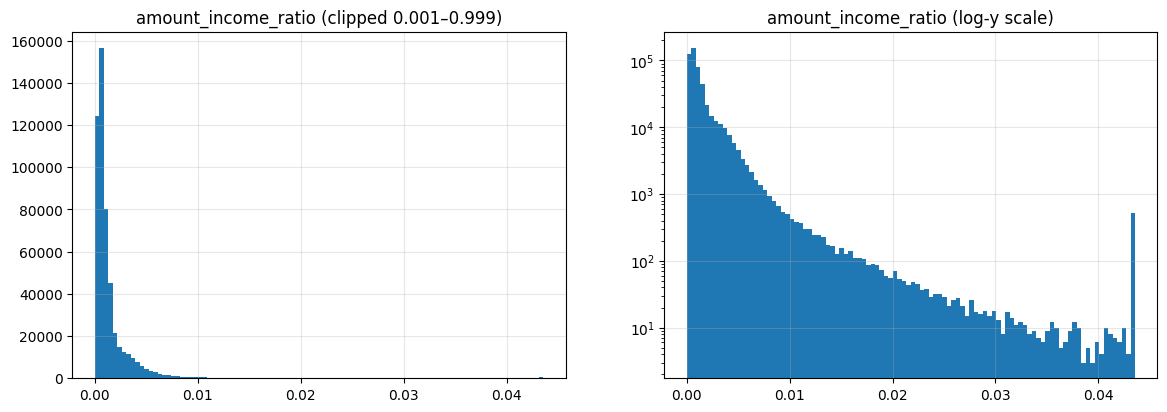

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ratio_distribution(df, col, clip_q=(0.001, 0.999)):
    s = df[col].astype(float)
    lo, hi = s.quantile(clip_q[0]), s.quantile(clip_q[1])
    clipped = s.clip(lo, hi)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

    # Linear scale
    ax[0].hist(clipped, bins=100)
    ax[0].set_title(f"{col} (clipped {clip_q[0]}–{clip_q[1]})")
    ax[0].grid(alpha=0.3)

    # Log scale
    ax[1].hist(clipped[clipped > 0], bins=100)
    ax[1].set_yscale("log")
    ax[1].set_title(f"{col} (log-y scale)")
    ax[1].grid(alpha=0.3)

    plt.show()

plot_ratio_distribution(df, "amount_income_ratio")

**raw ratio vs log ratio**

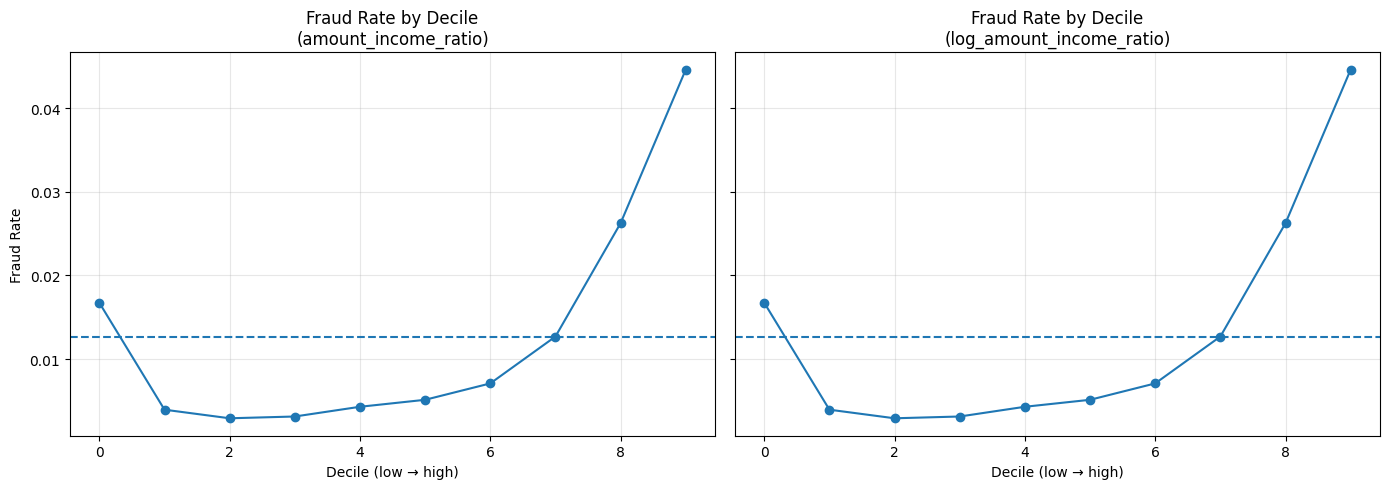

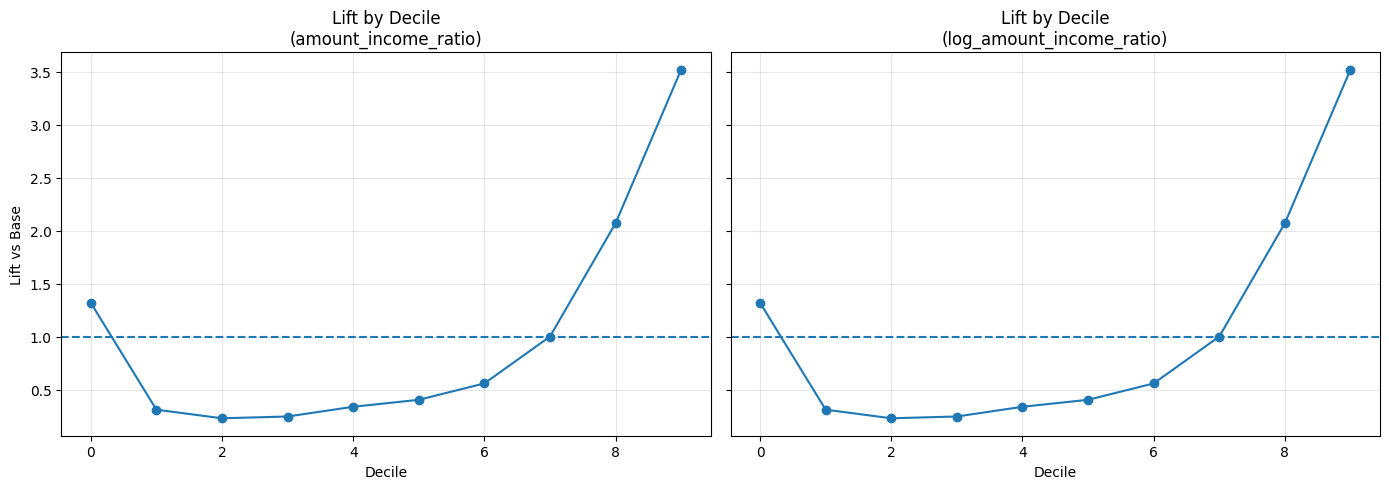

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL = "fraud"

def fraud_by_decile(df, col, n=10):
    tmp = df[[col, LABEL]].dropna().copy()
    tmp["decile"] = pd.qcut(tmp[col], n, duplicates="drop")
    g = tmp.groupby("decile", observed=True)[LABEL].mean().reset_index(drop=True)
    return g

base_rate = df[LABEL].mean()

raw_dec = fraud_by_decile(df, "amount_income_ratio")
log_dec = fraud_by_decile(df, "log_amount_income_ratio")

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].plot(raw_dec.values, marker="o")
axes[0].axhline(base_rate, linestyle="--")
axes[0].set_title("Fraud Rate by Decile\n(amount_income_ratio)")
axes[0].set_xlabel("Decile (low → high)")
axes[0].set_ylabel("Fraud Rate")
axes[0].grid(alpha=0.3)

axes[1].plot(log_dec.values, marker="o")
axes[1].axhline(base_rate, linestyle="--")
axes[1].set_title("Fraud Rate by Decile\n(log_amount_income_ratio)")
axes[1].set_xlabel("Decile (low → high)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

raw_lift = raw_dec / base_rate
log_lift = log_dec / base_rate

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].plot(raw_lift.values, marker="o")
axes[0].axhline(1.0, linestyle="--")
axes[0].set_title("Lift by Decile\n(amount_income_ratio)")
axes[0].set_xlabel("Decile")
axes[0].set_ylabel("Lift vs Base")
axes[0].grid(alpha=0.3)

axes[1].plot(log_lift.values, marker="o")
axes[1].axhline(1.0, linestyle="--")
axes[1].set_title("Lift by Decile\n(log_amount_income_ratio)")
axes[1].set_xlabel("Decile")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

> 

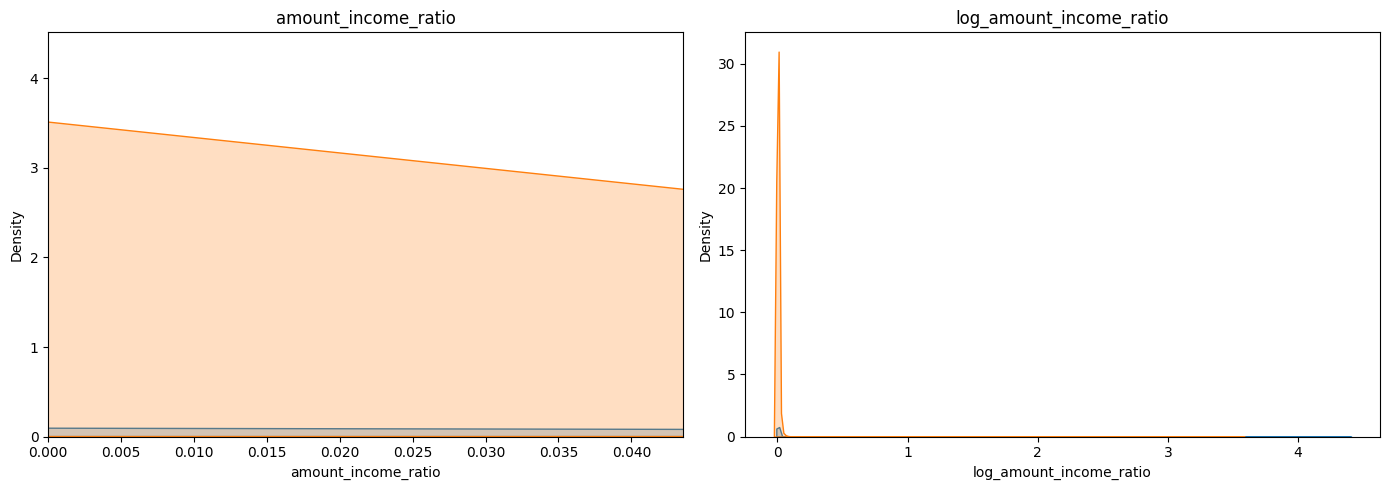

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x="amount_income_ratio",
    fill=True,
    common_norm=False,
    ax=axes[0]
)
sns.kdeplot(
    data=df[df[LABEL]==1],
    x="amount_income_ratio",
    fill=True,
    common_norm=False,
    ax=axes[0]
)
axes[0].set_xlim(0, df["amount_income_ratio"].quantile(0.999))
axes[0].set_title("amount_income_ratio")

sns.kdeplot(
    data=df[df[LABEL]==0],
    x="log_amount_income_ratio",
    fill=True,
    common_norm=False,
    ax=axes[1]
)
sns.kdeplot(
    data=df[df[LABEL]==1],
    x="log_amount_income_ratio",
    fill=True,
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("log_amount_income_ratio")

plt.tight_layout()
plt.show()

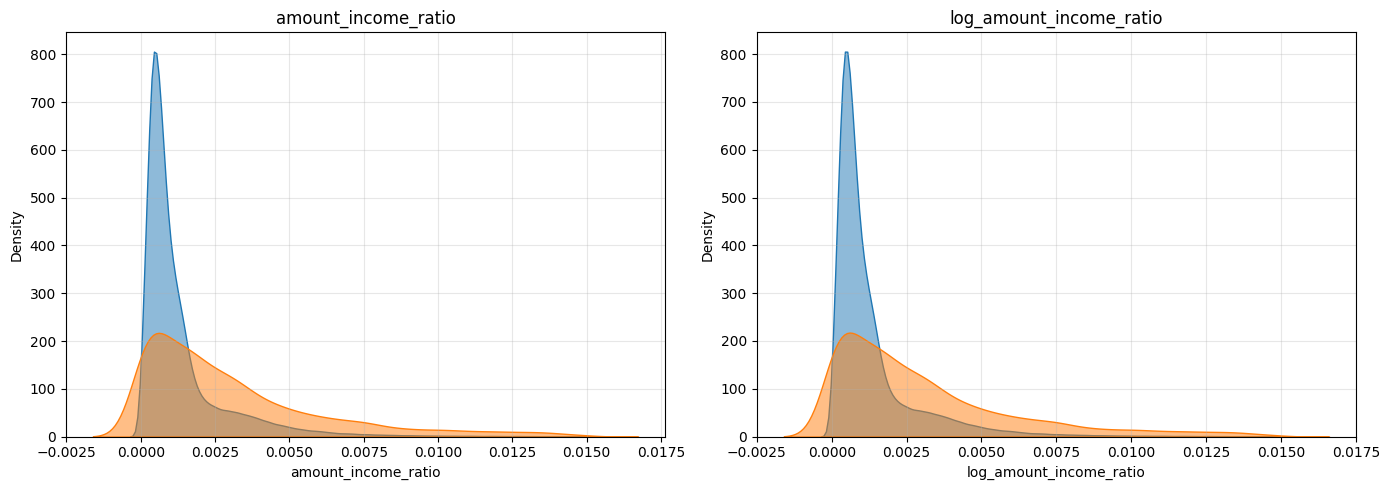

In [31]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

for label, ax in zip(
    ["amount_income_ratio", "log_amount_income_ratio"],
    axes
):
    tmp = df[[label, "fraud"]].copy()

    upper = tmp[label].quantile(0.995)  # 상위 0.5% 제거
    tmp = tmp[tmp[label] <= upper]

    sns.kdeplot(
        data=tmp[tmp["fraud"]==0],
        x=label,
        fill=True,
        alpha=0.5,
        ax=ax
    )
    sns.kdeplot(
        data=tmp[tmp["fraud"]==1],
        x=label,
        fill=True,
        alpha=0.5,
        ax=ax
    )

    ax.set_title(label)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

log 변환이 분리력을 개선하지 않는다.

**raw 장점**

직관적 해석 가능

"소득 대비 몇 배 소비" 의미 유지

트리 모델에서 그대로 사용 가능

**log 장점**

이론적으로 선형 모델 안정화

extreme value 영향 감소

**raw 사용**

분리력 차이 없음

로그 변환으로 얻는 안정성 이득 미미

해석력(raw가 더 직관적)

Stage2에서 트리 모델 쓰는 구조와 일관성

### ***amount_limit_ratio***

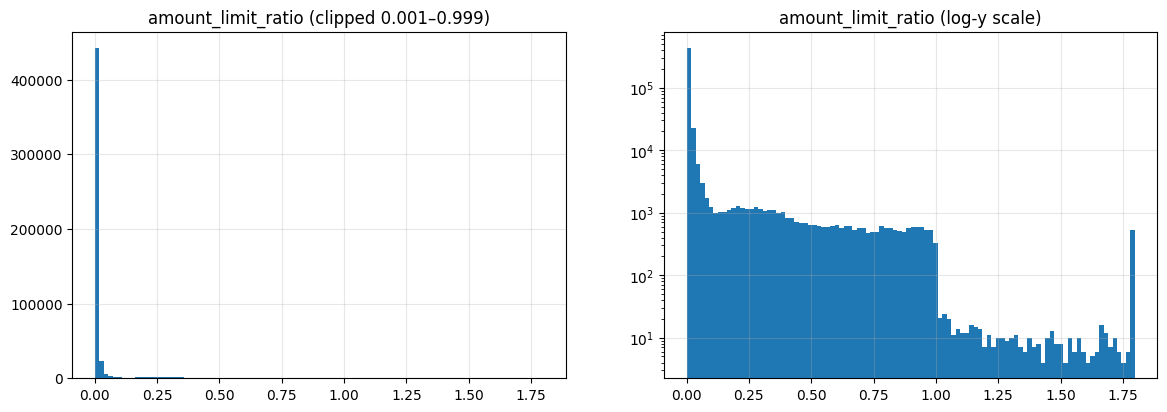

In [19]:
plot_ratio_distribution(df, "amount_limit_ratio")

In [64]:
df["amount_limit_ratio"].describe()

count    515188.000000
mean          0.047987
std           0.372918
min           0.000000
25%           0.001282
50%           0.002771
75%           0.008258
max         136.969864
Name: amount_limit_ratio, dtype: float64

In [20]:
print(df["credit_limit"].describe(percentiles=[.001,.01,.05,.5,.95,.99,.999]))

small_limit = df["credit_limit"] < df["credit_limit"].quantile(0.01)
print("하위 1% credit_limit fraud rate:", df.loc[small_limit, "fraud"].mean())
print("하위 1% credit_limit count:", small_limit.sum())

count    515188.000000
mean      16193.337891
std       12276.457031
min           1.000000
0.1%         27.000000
1%           44.000000
5%           74.000000
50%       14466.000000
95%       36912.000000
99%       57294.000000
99.9%     96637.000000
max      141391.000000
Name: credit_limit, dtype: float64
하위 1% credit_limit fraud rate: 0.02535101404056162
하위 1% credit_limit count: 5128


In [33]:
df["amount_limit_ratio"].describe()

count    515188.000000
mean          0.047987
std           0.372918
min           0.000000
25%           0.001282
50%           0.002771
75%           0.008258
max         136.969864
Name: amount_limit_ratio, dtype: float64

extreme right-skew + heavy tail 구조

대부분 거래는 한도의 1% 미만 사용\
그런데 일부 극단 케이스가 평균과 분산을 끌어올림

In [34]:
RATIO_COL = "amount_limit_ratio"
DENOM_COL = "credit_limit"          # 검증용 flag에 사용
RANDOM_STATE = 42
TEST_SIZE = 0.2

# clip 기준: 상위 q 분위수 
CLIP_Q = 0.999

def top_decile_lift(y_true, score, q=0.90):
    y = pd.Series(y_true).astype(int).reset_index(drop=True)
    s = pd.Series(score).astype(float).reset_index(drop=True)

    base_rate = float(y.mean())
    thr = float(np.quantile(s, q))

    top = s >= thr
    top_n = int(top.sum())
    if top_n == 0 or base_rate == 0:
        return {"base_rate": base_rate, "top_decile_rate": np.nan, "top_decile_lift": np.nan, "top_n": top_n, "thr": thr}

    top_rate = float(y[top].mean())
    return {"base_rate": base_rate, "top_decile_rate": top_rate, "top_decile_lift": float(top_rate / base_rate), "top_n": top_n, "thr": thr}


def fit_eval_logistic(df_in, cols):
    d = df_in[cols + [LABEL]].replace([np.inf, -np.inf], np.nan).dropna()
    X = d[cols]
    y = d[LABEL].astype(int)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    pipe = Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, solver="lbfgs")),
    ])

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict_proba(X_te)[:, 1]

    pr = float(average_precision_score(y_te, pred))
    lift = float(top_decile_lift(y_te, pred)["top_decile_lift"])
    return pr, lift


BASE_COLS = [c for c in ["log_abs_amount", "is_refund", "log_yearly_income"] if c in df.columns]
print("BASE_COLS:", BASE_COLS)

base_pr, base_lift = fit_eval_logistic(df, BASE_COLS)

dfv = df.copy()

# (1) Original ratio
dfv["limit_ratio_orig"] = dfv[RATIO_COL].astype(float)

# (2) Clip ratio (winsorize upper tail)
clip_upper = float(dfv["limit_ratio_orig"].quantile(CLIP_Q))
dfv["limit_ratio_clip"] = dfv["limit_ratio_orig"].clip(upper=clip_upper)

# (3) Original ratio + extreme flag
dfv["limit_ratio_extreme_flag"] = (dfv["limit_ratio_orig"] >= clip_upper).astype(int)

# (+) Optional: low credit_limit flag (분모 극저 여부)

cl_p01 = float(dfv[DENOM_COL].quantile(0.01))
dfv["low_credit_limit_flag"] = (dfv[DENOM_COL] <= cl_p01).astype(int)

rows = []

# (1) add original
pr1, lift1 = fit_eval_logistic(dfv, BASE_COLS + ["limit_ratio_orig"])
rows.append({
    "variant": "orig_ratio",
    "added": "limit_ratio_orig",
    "PR_AUC": pr1,
    "PR_AUC_delta": pr1 - base_pr,
    "TopDecileLift": lift1,
    "Lift_delta": lift1 - base_lift,
})

# (2) add clipped
pr2, lift2 = fit_eval_logistic(dfv, BASE_COLS + ["limit_ratio_clip"])
rows.append({
    "variant": f"clip_ratio_q{CLIP_Q}",
    "added": "limit_ratio_clip",
    "PR_AUC": pr2,
    "PR_AUC_delta": pr2 - base_pr,
    "TopDecileLift": lift2,
    "Lift_delta": lift2 - base_lift,
})

# (3) add original + flags
cols3 = BASE_COLS + ["limit_ratio_orig", "limit_ratio_extreme_flag", "low_credit_limit_flag"]
pr3, lift3 = fit_eval_logistic(dfv, cols3)
rows.append({
    "variant": "orig_plus_flags",
    "added": "limit_ratio_orig + extreme_flag + low_credit_limit_flag",
    "PR_AUC": pr3,
    "PR_AUC_delta": pr3 - base_pr,
    "TopDecileLift": lift3,
    "Lift_delta": lift3 - base_lift,
})

result_df = pd.DataFrame(rows).sort_values("Lift_delta", ascending=False)

print("Base PR_AUC:", base_pr, "Base Lift:", base_lift)
display(result_df)

print("clip_upper used:", clip_upper)
print("low_credit_limit_p01:", cl_p01)

BASE_COLS: ['log_abs_amount', 'is_refund', 'log_yearly_income']
Base PR_AUC: 0.04765955079708661 Base Lift: 3.6112535463604956


,variant,added,PR_AUC,PR_AUC_delta,TopDecileLift,Lift_delta
0,orig_ratio,limit_ratio_orig,0.083801,0.036141,3.940245,0.328991
2,orig_plus_flags,limit_ratio_orig + extreme_flag + low_credit_l...,0.103338,0.055678,3.810179,0.198925
1,clip_ratio_q0.999,limit_ratio_clip,0.106932,0.059273,3.618905,0.007651


clip_upper used: 1.798450042128616
low_credit_limit_p01: 44.0


> raw 유지

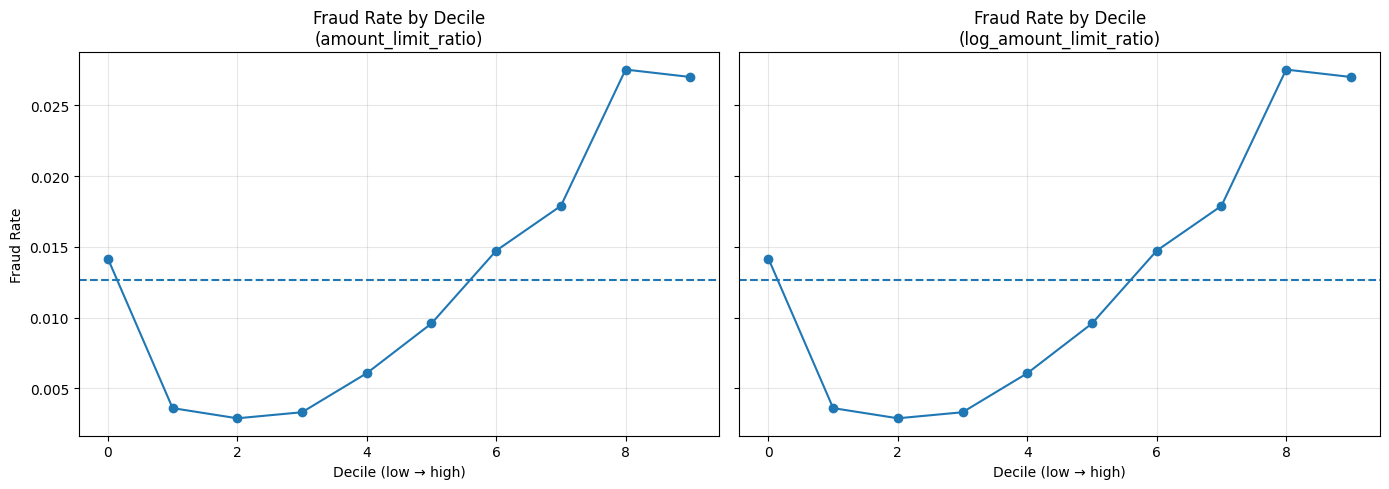

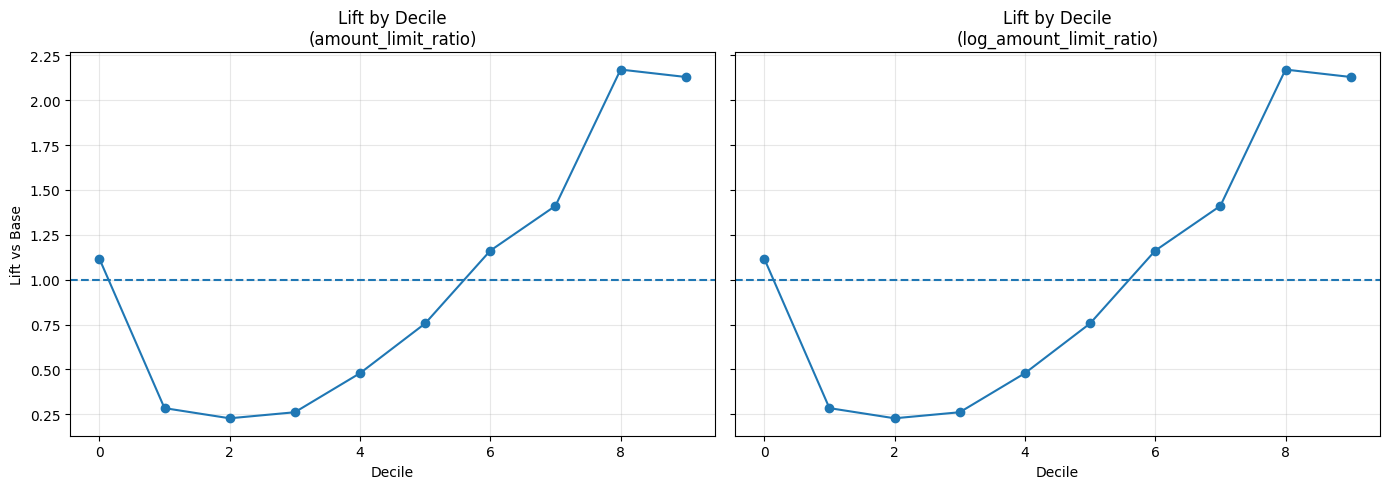

In [35]:
base_rate = df[LABEL].mean()

raw_dec = fraud_by_decile(df, "amount_limit_ratio")
log_dec = fraud_by_decile(df, "log_amount_limit_ratio")

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].plot(raw_dec.values, marker="o")
axes[0].axhline(base_rate, linestyle="--")
axes[0].set_title("Fraud Rate by Decile\n(amount_limit_ratio)")
axes[0].set_xlabel("Decile (low → high)")
axes[0].set_ylabel("Fraud Rate")
axes[0].grid(alpha=0.3)

axes[1].plot(log_dec.values, marker="o")
axes[1].axhline(base_rate, linestyle="--")
axes[1].set_title("Fraud Rate by Decile\n(log_amount_limit_ratio)")
axes[1].set_xlabel("Decile (low → high)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

raw_lift = raw_dec / base_rate
log_lift = log_dec / base_rate

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].plot(raw_lift.values, marker="o")
axes[0].axhline(1.0, linestyle="--")
axes[0].set_title("Lift by Decile\n(amount_limit_ratio)")
axes[0].set_xlabel("Decile")
axes[0].set_ylabel("Lift vs Base")
axes[0].grid(alpha=0.3)

axes[1].plot(log_lift.values, marker="o")
axes[1].axhline(1.0, linestyle="--")
axes[1].set_title("Lift by Decile\n(log_amount_limit_ratio)")
axes[1].set_xlabel("Decile")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

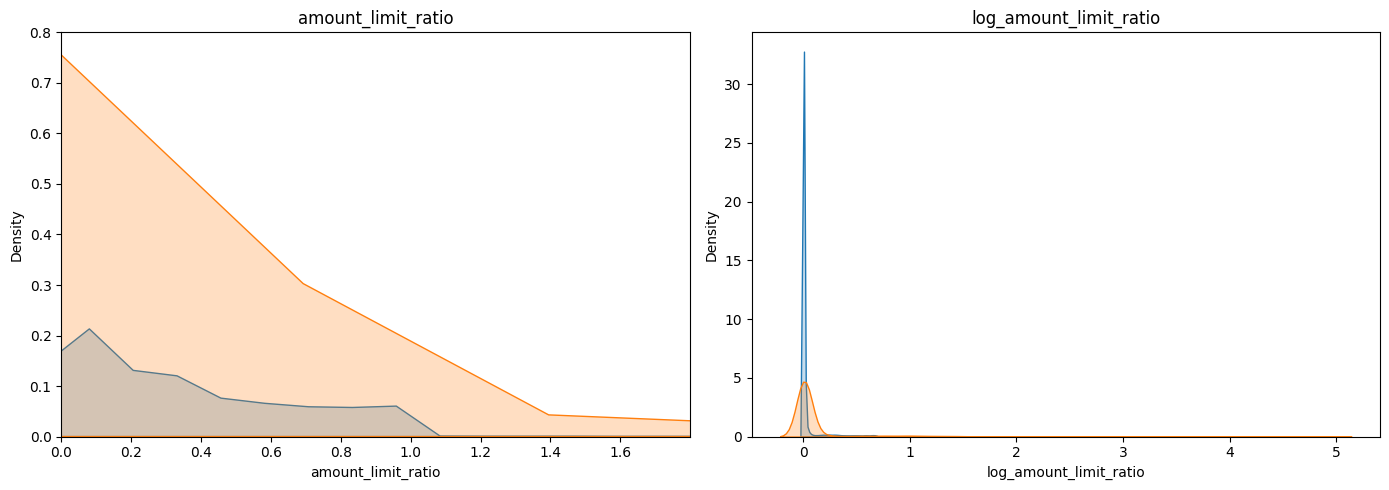

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x="amount_limit_ratio",
    fill=True,
    common_norm=False,
    ax=axes[0]
)
sns.kdeplot(
    data=df[df[LABEL]==1],
    x="amount_limit_ratio",
    fill=True,
    common_norm=False,
    ax=axes[0]
)
axes[0].set_xlim(0, df["amount_limit_ratio"].quantile(0.999))
axes[0].set_title("amount_limit_ratio")

sns.kdeplot(
    data=df[df[LABEL]==0],
    x="log_amount_limit_ratio",
    fill=True,
    common_norm=False,
    ax=axes[1]
)
sns.kdeplot(
    data=df[df[LABEL]==1],
    x="log_amount_limit_ratio",
    fill=True,
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("log_amount_limit_ratio")

plt.tight_layout()
plt.show()

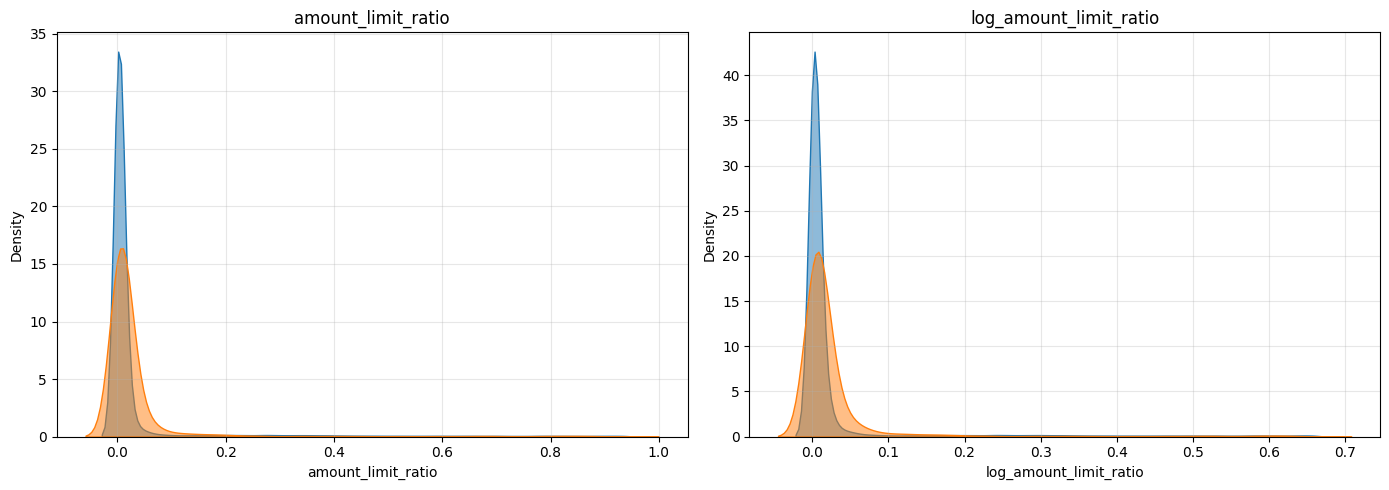

In [37]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

for label, ax in zip(
    ["amount_limit_ratio", "log_amount_limit_ratio"],
    axes
):
    tmp = df[[label, "fraud"]].copy()

    upper = tmp[label].quantile(0.995)  # 상위 0.5% 제거
    tmp = tmp[tmp[label] <= upper]

    sns.kdeplot(
        data=tmp[tmp["fraud"]==0],
        x=label,
        fill=True,
        alpha=0.5,
        ax=ax
    )
    sns.kdeplot(
        data=tmp[tmp["fraud"]==1],
        x=label,
        fill=True,
        alpha=0.5,
        ax=ax
    )

    ax.set_title(label)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Fraud Rate by Decile**

두 그래프 거의 동일하다.

상위 decile 급상승

하위 decile 낮음

단조 증가 구조 유지

→ log 변환이 순위 구조를 거의 안 바꿈

**Lift by Decile**

완전히 동일 패턴.

→ 순위 기반 metric에서는 차이 거의 없음

...

분포 비교

raw는 극단 tail 존재

log는 분포 압축됨

하지만 fraud 분리 패턴은 비슷

***=> amount limit ratio raw 그대로 사용***

In [51]:
thr = df["amount_limit_ratio"].quantile(0.999)
df[df["amount_limit_ratio"] >= thr]["fraud"].mean()

np.float64(0.6647286821705426)

In [53]:
df["limit_ratio_extreme"] = (df["amount_limit_ratio"] >= thr).astype(int)

### ***amount income & limit ratio***

In [22]:
cols = BASE_COLS + ["amount_income_ratio", "amount_limit_ratio"]

pr_both, lift_both = fit_eval_logistic_addone(dfv, BASE_COLS + ["amount_income_ratio"], "amount_limit_ratio")

print("Both ratios PR-AUC:", pr_both)
print("Both ratios Lift:", lift_both)

Both ratios PR-AUC: 0.08598744633856298
Both ratios Lift: 3.9784996697191897


> 두 ratio는 서로 다른 리스크 축을 설명한다.

In [23]:
df[["amount_income_ratio", "amount_limit_ratio"]].corr()

,amount_income_ratio,amount_limit_ratio
amount_income_ratio,1.000000,0.069963
amount_limit_ratio,0.069963,1.000000


In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vif_cols = ['log_abs_amount', 'amount_income_ratio', 
            'amount_limit_ratio', 'limit_ratio_extreme', 'is_refund']
X_vif = df[vif_cols].dropna()
X_vif_const = sm.add_constant(X_vif)
vif = pd.DataFrame({
    'feature': X_vif_const.columns,
    'VIF': [variance_inflation_factor(X_vif_const.values, i) 
            for i in range(X_vif_const.shape[1])]
})
print(vif)

               feature        VIF
0                const  16.626390
1       log_abs_amount   1.027584
2  amount_income_ratio   1.006232
3   amount_limit_ratio   1.377853
4  limit_ratio_extreme   1.373890
5            is_refund   1.026512


> 다중공선성 문제 없음

저소득자가 갑자기 큰 금액 사용

한도 거의 다 써가면서 사용

혹은 한도 낮은 카드에서 큰 금액 시도

이런 케이스는 fraud일 확률이 높다.

### ***Income***
- yearly_icome
- log_yearly_icome
- log_income_ratio_region

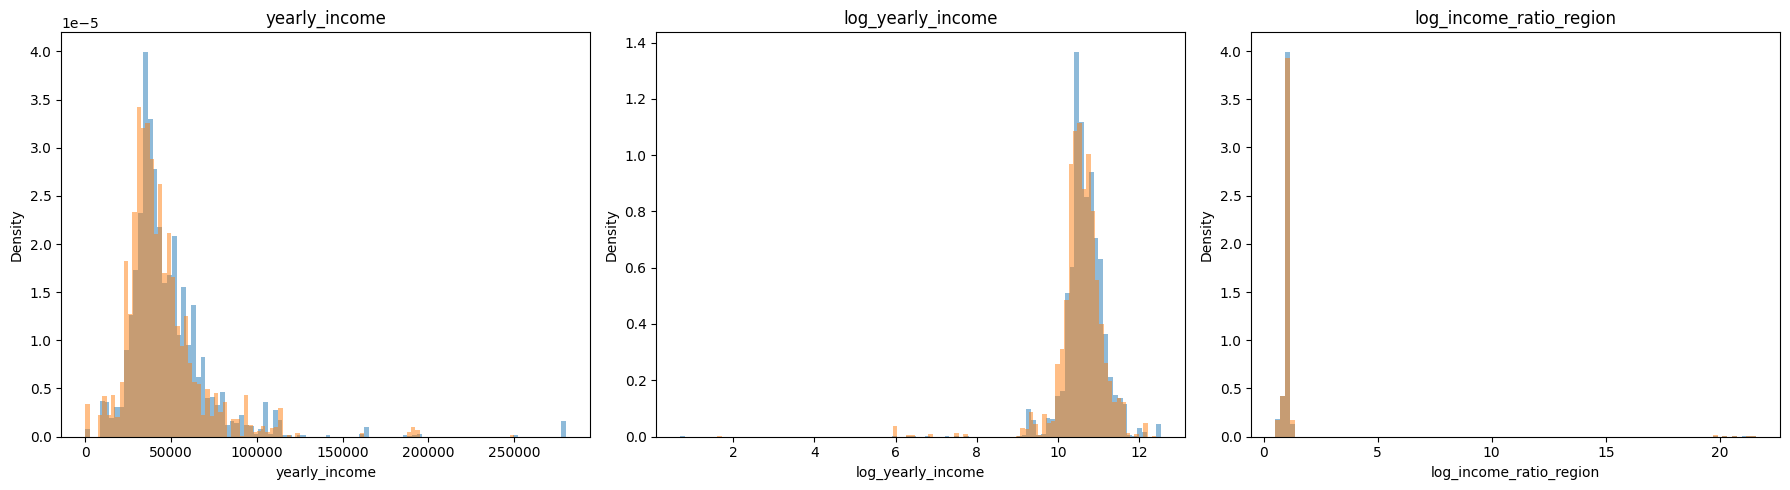

In [40]:
import matplotlib.pyplot as plt
import numpy as np

cols = ["yearly_income", "log_yearly_income", "log_income_ratio_region"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cols):
    if col not in df.columns:
        ax.set_title(f"{col} not found")
        continue
    
    data = df[[col, "fraud"]].replace([np.inf, -np.inf], np.nan).dropna()
    
    fraud0 = data[data["fraud"] == 0][col]
    fraud1 = data[data["fraud"] == 1][col]
    
    ax.hist(fraud0, bins=100, density=True, alpha=0.5)
    ax.hist(fraud1, bins=100, density=True, alpha=0.5)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

income 절대값 변수는

✔ 독립적 분리력 없음
✔ ratio에 의해 설명됨
✔ 선형 모델에서 중복 가능성 있음

### ***is_refund***

In [42]:
df.groupby("is_refund")[LABEL].mean()

is_refund
0    0.012151
1    0.106390
Name: fraud, dtype: float64

In [43]:
df.groupby("fraud")["is_refund"].mean()

fraud
0    0.005086
1    0.047145
Name: is_refund, dtype: float64

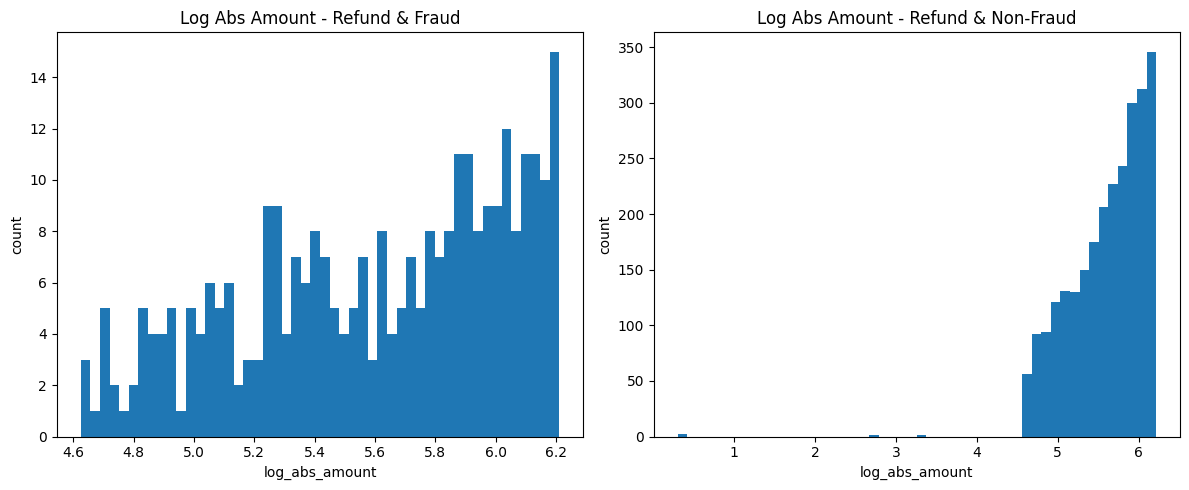

Mean amount (refund+fraud): -294.41882
Mean amount (refund+nonfraud): -296.86032


In [44]:
df_rf = df[(df["is_refund"] == 1) & (df["fraud"] == 1)]
df_rn = df[(df["is_refund"] == 1) & (df["fraud"] == 0)]

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(np.abs(df_rf["amount"])), bins=50)
plt.title("Log Abs Amount - Refund & Fraud")
plt.xlabel("log_abs_amount")
plt.ylabel("count")

plt.subplot(1, 2, 2)
plt.hist(np.log1p(np.abs(df_rn["amount"])), bins=50)
plt.title("Log Abs Amount - Refund & Non-Fraud")
plt.xlabel("log_abs_amount")
plt.ylabel("count")

plt.tight_layout()
plt.show()

print("Mean amount (refund+fraud):", df_rf["amount"].mean())
print("Mean amount (refund+nonfraud):", df_rn["amount"].mean())


lift 기준 적용 대상 아님

이미 high-risk binary feature

### ***total_debt***

In [45]:
df["total_debt"].describe(percentiles=[0.001, 0.01, 0.05, 0.95, 0.99, 0.999])

count    515188.000000
mean      58821.851562
std       49313.257812
min           0.000000
0.1%          0.000000
1%            0.000000
5%          323.000000
50%       52248.000000
95%      145300.000000
99%      219213.000000
99.9%    328089.000000
max      461854.000000
Name: total_debt, dtype: float64

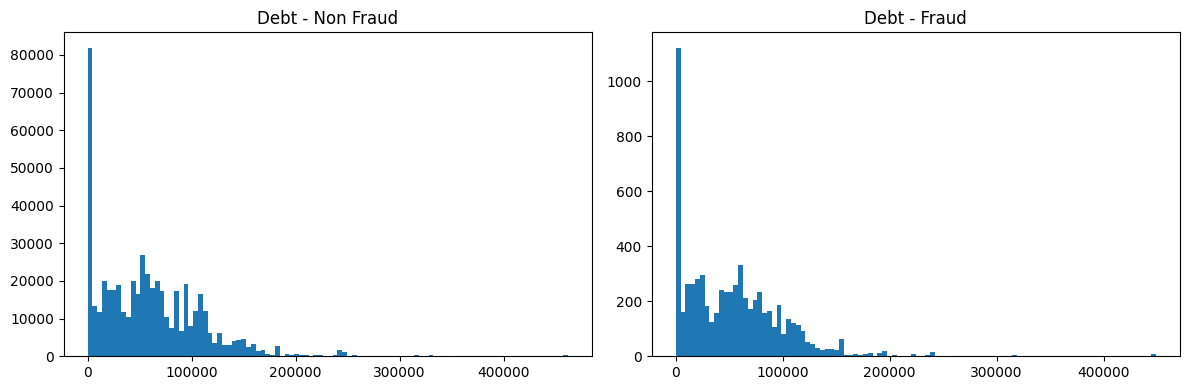

In [46]:
import matplotlib.pyplot as plt
import numpy as np

d = df[["total_debt", "fraud"]].replace([np.inf, -np.inf], np.nan).dropna()

fraud0 = d[d["fraud"] == 0]["total_debt"]
fraud1 = d[d["fraud"] == 1]["total_debt"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fraud0, bins=100)
axes[0].set_title("Debt - Non Fraud")

axes[1].hist(fraud1, bins=100)
axes[1].set_title("Debt - Fraud")

plt.tight_layout()
plt.show()

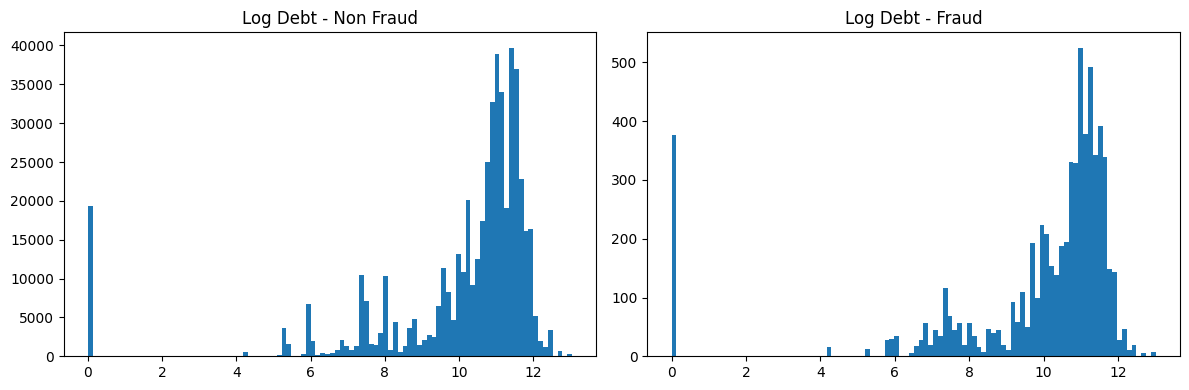

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.log1p(fraud0), bins=100)
axes[0].set_title("Log Debt - Non Fraud")

axes[1].hist(np.log1p(fraud1), bins=100)
axes[1].set_title("Log Debt - Fraud")

plt.tight_layout()
plt.show()

In [50]:
tmp = df[["total_debt", "fraud"]].dropna().copy()
tmp["decile"] = pd.qcut(tmp["total_debt"], 10, duplicates="drop")

dec = tmp.groupby("decile")["fraud"].mean().reset_index()
dec["lift"] = dec["fraud"] / df["fraud"].mean()

display(dec)

/tmp/ipykernel_3597804/3822137488.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dec = tmp.groupby("decile")["fraud"].mean().reset_index()


,decile,fraud,lift
0,"(-0.001, 1644.0]",0.015609,1.230909
1,"(1644.0, 12241.0]",0.012810,1.010184
2,"(12241.0, 24637.0]",0.015777,1.244177
3,"(24637.0, 41455.0]",0.011478,0.905122
4,"(41455.0, 52248.0]",0.011978,0.944604
5,"(52248.0, 64073.0]",0.013556,1.068997
6,"(64073.0, 79960.0]",0.013871,1.093843
7,"(79960.0, 97881.0]",0.012505,0.986125
8,"(97881.0, 119230.0]",0.010280,0.810691
9,"(119230.0, 461854.0]",0.008855,0.698277


단조 증가 없음

고부채에서 오히려 fraud 감소

구조적 리스크 축 아님

---

In [54]:
KEEP_COLS = [
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",
    "limit_ratio_extreme",
    "is_refund",
]

In [57]:
BASELINE = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

In [60]:

def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

for col in KEEP_COLS:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,amount_income_ratio,0.017225,1.017374,3.085905e-01,0.044644,3.520574,51519
1,log_abs_amount,0.646936,1.909680,0.000000e+00,0.043803,3.454285,51526
2,amount_limit_ratio,0.710871,2.035763,6.359225e-178,0.027000,2.129182,51519
3,limit_ratio_extreme,5.092934,162.866946,0.000000e+00,0.012681,1.000000,515188
4,is_refund,2.269943,9.678851,3.768287e-297,0.012681,1.000000,515188


In [61]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in KEEP_COLS:
    if col in BASELINE:
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.012680807782789972, 'top_decile_rate': 0.04941866107649605, 'top_decile_lift': 3.8971224801282482, 'thr': 0.023932375490811033, 'top_n': 51519}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,limit_ratio_extreme,OK,4.024199,55.935475,5.156060e-240,0.012681,0.050312,3.967534,0.000893,0.070411,51519.0
1,is_refund,OK,1.194767,3.302789,6.115354e-71,0.012681,0.049555,3.907837,0.000136,0.010715,51519.0
2,log_abs_amount,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,amount_income_ratio,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,amount_limit_ratio,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**KEEP**


["log_abs_amount",\
"limit_ratio_extreme",\
"is_refund"]

---
# EDA — Money Feature 분석 요약

## 1. 분석 대상 피처 목록

| 그룹 | 피처 |
|---|---|
| Raw Amount | `amount`, `abs_amount`, `is_refund` |
| Log Amount | `log_abs_amount`, `log_yearly_income`, `log_amount_income_ratio`, `log_amount_limit_ratio`, `log_income_ratio_region` |
| Ratio | `amount_income_ratio`, `amount_limit_ratio`, `income_ratio_region` |
| Income/Debt Context | `per_capita_income`, `yearly_income`, `total_debt` |

---

## 2. 핵심 인사이트: Fraud는 절대 금액이 아닌 "상대적 과소비"에서 발생한다

> 단순히 금액이 크다고 사기가 아니라, **개인 소득 대비** 또는 **카드 한도 대비** 과도한 금액일 때 사기 확률이 높아진다.

Ratio 계열이 raw 금액 계열보다 일관되게 높은 분리력을 보인다.

---

## 3. Raw vs Log 변환 비교

KS 통계량과 PR-AUC가 raw와 log 변환 사이에서 완전히 동일하다.

| Pair | KS_raw | KS_log | PR_AUC_raw | PR_AUC_log |
|---|---|---|---|---|
| abs_amount / log_abs_amount | 0.420 | 0.420 | 0.040 | 0.040 |
| yearly_income / log_yearly_income | 0.098 | 0.098 | 0.011 | 0.011 |
| amount_income_ratio / log_amount_income_ratio | 0.384 | 0.384 | 0.045 | 0.045 |

| amount_limit_ratio / log_amount_limit_ratio | 0.287 | 0.287 | 0.071 | 0.071 |

순위 기반 metric에서는 단조 로그 변환이 분리력을 바꾸지 않는다. 차이는 선형 모델의 안정성 및 극단값 완화에서만 발생한다.

> **raw 형태 유지 결정**: 해석력이 더 직관적이고, 트리 모델과의 일관성 유지. 로그 변환으로 얻는 안정성 이득이 미미.

---

## 4. Add-one Δ Lift 분석 (Baseline 대비)

Baseline: `log_abs_amount`, `is_refund`, `log_yearly_income`

| Candidate | Δ PR_AUC | Δ Lift | 비고 |
|---|---|---|---|
| **amount_limit_ratio** | **+0.036** | **+0.329** | 압도적 1위 |
| log_amount_limit_ratio | +0.051 | +0.069 | — |
| amount_income_ratio | +0.003 | +0.061 | — |
| per_capita_income | +0.002 | +0.069 | amount_income_ratio와 중복 |
| total_debt | +0.001 | +0.023 | — |
| income_ratio_region | -0.000 | 0.000 | 추가 설명력 없음 |
| abs_amount | -0.001 | -0.015 | log_abs_amount에 흡수 |
| amount | -0.001 | -0.023 | log_abs_amount에 흡수 |

---

## 5. amount_income_ratio 심층 분석

KS 통계량 0.38 — 가장 강한 fraud 분리 신호 중 하나. Decile 상위 구간에서 fraud rate가 급증하는 단조 상승 구조 확인.

### yearly_income 극단값 처리 검토

`yearly_income < 1000`인 구간(전체 하위 0.1%)에서 fraud rate 6.4%로 base rate의 약 5배. `amount_income_ratio > 1`인 케이스의 거의 대부분이 `yearly_income ≤ 553`인 이상 레코드.

| 처리 방법 | Δ Lift |
|---|---|
| 원본 ratio (clip 없음) | +0.061 |
| 원본 + low_income_flag 추가 | +0.061 |
| income clip 후 ratio 재계산 | **-0.038** |

income을 clip해서 ratio tail을 제거하면 오히려 성능이 하락한다. ratio tail 일부가 실제 모델 성능에 기여하고 있으며, `low_income_flag`는 추가 정보량이 거의 없다.

> **결론: 원본 `amount_income_ratio` 그대로 유지.**

---

## 6. amount_limit_ratio 심층 분석

PR_AUC 단독 0.071 — 단일 피처 기준 최고값. Δ Lift +0.329 — add-one 검증 압도적 1위.

분포는 extreme right-skew + heavy tail 구조. 대부분 거래는 한도의 1% 미만을 사용하지만, 극단 케이스(한도의 100배 이상)가 존재한다.

### 극단값 처리 검토 (CLIP_Q = 0.999)

| 처리 방법 | Δ PR_AUC | Δ Lift |
|---|---|---|
| 원본 ratio | +0.036 | **+0.329** |
| 원본 + extreme_flag + low_credit_flag | +0.056 | +0.199 |
| clip ratio (q0.999) | +0.059 | +0.008 |

clip 처리 시 PR_AUC는 높아지지만 Top-decile Lift가 크게 하락한다. 극단값 자체가 fraud 신호의 핵심임을 시사한다. `amount_limit_ratio ≥ q0.999` 구간의 fraud rate = **66.5%**.

> **결론: 원본 `amount_limit_ratio` 유지 + `limit_ratio_extreme` (이진 flag) 추가 생성.**

### 두 ratio 간 상관관계

`corr(amount_income_ratio, amount_limit_ratio) = 0.070`

두 ratio는 서로 다른 리스크 축을 설명하며, 다중공선성 문제 없이 동시 사용 가능하다.

---

## 7. is_refund 분석

| is_refund | Fraud Rate | Lift |
|---|---|---|
| 0 | 1.22% | — |
| 1 | **10.64%** | **~8.4배** |

환불 거래 자체가 구조적 고위험 신호. Refund 집단 내 fraud vs non-fraud 간 금액 분포 차이가 거의 없음(평균 -294 vs -297) — 금액이 아닌 거래 행위 자체가 신호다.

다변량 검증에서도 Baseline 대비 Δ Lift +0.011 유지. 이미 high-risk binary feature이므로 추가 변환 없이 그대로 사용한다.

---

## 8. Income/Debt 계열 분석

**yearly_income / log_yearly_income**: 단독 분리력 약함(KS 0.098). 소득 절대값 자체가 fraud를 구별하지 못하며, ratio를 통해서만 의미가 생긴다.

**total_debt**: 단조 증가 구조가 없고 오히려 고부채에서 fraud가 감소하는 역패턴을 보인다.

| Decile | Fraud Rate | Lift |
|---|---|---|
| 1 (최저 부채) | 0.0156 | 1.23 |
| 5~6 (중간) | 0.012~0.014 | ~1.0 |
| 10 (최고 부채) | 0.0089 | 0.70 |

구조적 리스크 축이 아니며, 고부채 사용자가 오히려 정상 소비 패턴을 가질 수 있음을 시사한다.

---

## 9. 최종 피처 결정

### ✅ KEEP

| Feature | 역할 | 근거 |
|---|---|---|
| `log_abs_amount` | 거래 규모 신호 | KS 0.42, 단독 Top-decile Lift 3.45, 로그 변환으로 선형 모델 안정화 |
| `amount_income_ratio` | 소득 대비 과소비 신호 | KS 0.38, raw 그대로 유지 (clip 시 성능 하락) |
| `amount_limit_ratio` | 한도 대비 과소비 신호 | KS 0.29, PR_AUC 단독 최고(0.071), add-one Δ Lift 압도적 1위(+0.329) |
| `limit_ratio_extreme` | 한도 초과 극단 이벤트 flag | `amount_limit_ratio ≥ q0.999` 구간 fraud rate 66.5%, 다변량 Δ Lift +0.070 |
| `is_refund` | 환불 거래 고위험 flag | fraud rate 10.6%(base 대비 8.4배), 다변량 Δ Lift +0.011 |

### ❌ DROP

| Feature | 사유 |
|---|---|
| `amount` / `abs_amount` | `log_abs_amount`에 흡수됨. 다변량 add-one에서 성능 감소 |
| `log_amount_income_ratio` / `log_amount_limit_ratio` | raw ratio와 분리력 동일. raw가 해석력 우위 |
| `yearly_income` / `log_yearly_income` | 단독 분리력 약함(KS 0.098). ratio를 통해서만 의미 있음 |
| `per_capita_income` | `amount_income_ratio`와 중복 정보 |
| `income_ratio_region` / `log_income_ratio_region` | add-one 추가 설명력 없음 (Δ Lift ≈ 0) |
| `total_debt` | 단조 구조 없음. 고부채에서 오히려 fraud 감소 (역패턴) |

---

## 10. 최종 Money Feature Set 요약

| Category | Feature | 비고 |
|---|---|---|
| Amount Scale | `log_abs_amount` | 로그 변환으로 선형 모델 안정화 |
| Relative Risk (Income) | `amount_income_ratio` | raw 그대로 사용, clip 불필요 |
| Relative Risk (Limit) | `amount_limit_ratio` | raw 그대로 사용, clip 불필요 |
| Extreme Event Flag | `limit_ratio_extreme` | `amount_limit_ratio ≥ q0.999` binary flag |
| Behavioral Signal | `is_refund` | 구조적 고위험 이벤트 |